# Entregable Hito 1: Analisis exploratorio y preparación de datos
## PFC - Sistema Inteligente de Precios Dinámicos
**Autor:** Ricardo Fernández 
---

## 1. Introducción y Justificación de la Arquitectura

En la fase anterior (**Hito 0**), completamos con éxito el diseño y despliegue del pipeline de datos e infraestructura cloud. Este sistema capturó y procesó de forma híbrida tres tipos de fuentes de datos operacionales de distinta naturaleza física:
1.  **Amazon RDS (PostgreSQL)**: Contiene el inventario maestro estructurado y relacional de propiedades (`listings_master`).
2.  **MongoDB Atlas**: Almacena el corpus documental semiestructurado (JSON NoSQL) de reseñas históricas (`reviews_raw`).
3.  **Apache Kafka**: Captura y drena en tiempo real las interacciones dinámicas de navegación de los usuarios (clickstream).

Utilizando un clúster serverless de **AWS Glue con Apache Spark**, realizamos una federación de datos, cruzando las fuentes a través de la clave común `listing_id` y persistiendo los resultados en formato columnar optimizado **Apache Parquet** en nuestro bucket de **Amazon S3**.

Debido a la naturaleza de procesamiento distribuido del clúster de Spark, la salida se guardó fragmentada en aproximadamente 20 archivos Parquet individuales.

### Objetivos de esta Primera Mitad del Hito 1:
El propósito de este análisis consiste en bajar los datos consolidados de la nube, unificarlos localmente para agilizar los tiempos de respuesta y realizar un **Análisis Exploratorio de Datos (EDA)** exhaustivo que determine la calidad, patrones y relaciones de nuestro dataset antes de proceder al entrenamiento de modelos predictivos.


### 1. Importación de Librerías y Configuración de Visualizaciones

In [54]:
import os
import glob
import json
import time
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
import boto3
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Configuración de estilos visuales
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 7)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

# Cargar credenciales de AWS desde el archivo .env local
raiz_proyecto = Path.cwd().parent
env_path = raiz_proyecto / ".env"
load_dotenv(dotenv_path=env_path, override=True)

True

### 2. Ingesta Cloud Unificada a `/datasets/importado`

Para optimizar costes de cómputo en la nube y latencias de red en el cuaderno de Jupyter, utilizaremos la API de `boto3` para descargar secuencialmente los fragmentos distribuidos desde el Data Lake en S3. 

Posteriormente, utilizaremos las capacidades de lectura paralela de Pandas para unificar todos los fragmentos en memoria RAM y guardaremos un único archivo unificado consolidado bajo el formato binario optimizado Parquet en el directorio del proyecto `/datasets/importado/dataset_unificado.parquet`, de forma que para futuras comprobaciones o ejecuciones del cuaderno podamos omitir el siguiente bloque de código, y evitarnos tener que conectarnos a AWS cada vez.

In [ ]:
# Configurar rutas nativas usando Path (Evita problemas de slash '/' o '\' en Windows)
bucket_name = os.getenv("S3_BUCKET_NAME")
prefix_s3 = "curated/dataset_proptech_master/"
ruta_destino_local = raiz_proyecto / "datasets" / "importado"

# Asegurar la existencia física de la carpeta local de importación
os.makedirs(ruta_destino_local, exist_ok=True)

print("☁ Conectando con Amazon S3 con credenciales actualizadas...")
s3_res = boto3.resource('s3')
bucket = s3_res.Bucket(bucket_name)

count_descargas = 0
# Descargar iterativamente todos los fragmentos part-*.parquet del clúster
for obj in bucket.objects.filter(Prefix=prefix_s3):
    if obj.key.endswith('.parquet'):
        nombre_archivo = os.path.basename(obj.key)
        ruta_archivo_local = ruta_destino_local / nombre_archivo
        print(f"   📥 Descargando fragmento analítico: {nombre_archivo}")
        bucket.download_file(obj.key, str(ruta_archivo_local))
        count_descargas += 1

print(f"\n✔ Descargados con éxito {count_descargas} fragmentos Parquet.")
print("🔀 Unificando fragmentos locales en memoria RAM...")

# Pandas lee la carpeta entera heredando esquemas automáticamente
df_unificado = pd.read_parquet(str(ruta_destino_local))

print("🗑 Limpiando archivos fragmentados temporales de la carpeta...")
archivos_temporales = glob.glob(os.path.join(str(ruta_destino_local), "part-*"))
for f in archivos_temporales:
    os.remove(f)

# Persistencia del tablón de análisis unificado final
ruta_parquet_final = ruta_destino_local / "dataset_unificado.parquet"
df_unificado.to_parquet(str(ruta_parquet_final), index=False)

print("\n" + "="*70)
print("🌟 ¡PROCESO DE INGESTA AUTOMATIZADA FINALIZADO CORECTAMENTE!")
print(f"📂 Archivo unificado exportado a: {ruta_parquet_final.resolve()}")
print(f"📊 Dimensiones del dataset unificado: {df_unificado.shape[0]} filas y {df_unificado.shape[1]} columnas.")
print("="*70)

### 3. Inspección Inicial y Auditoría de Completitud de Datos

Una vez consolidado el tablón de datos multimodelo en nuestro entorno local, el primer paso fundamental del **Análisis Exploratorio de Datos (EDA)** consiste en realizar una inspección empírica de su estructura. 

Esta fase inicial tiene tres objetivos metodológicos clave:
1. **Validación del Esquema**: Verificar que las columnas clave del inventario de propiedades (`price`, `accommodates`, `room_type`) y las métricas cruzadas de MongoDB (`total_reviews_historicas`) y Kafka (`total_clicks_acumulados`) se hayan estructurado correctamente.
2. **Auditoría de Completitud**: Cuantificar la presencia de valores ausentes (`NaN` o nulos) introducidos durante la fase de extracción o causados por la naturaleza de los registros (por ejemplo, alojamientos sin clics acumulados o sin reseñas).
3. **Mapeo de Cardinalidad**: Evaluar el volumen de valores únicos por columna para identificar de forma temprana variables categóricas de alta dispersión.

In [55]:
# Definir la ruta física al archivo consolidado
raiz_proyecto = Path.cwd().parent
ruta_archivo_parquet = raiz_proyecto / "datasets" / "importado" / "dataset_unificado.parquet"

pd.set_option('display.max_rows', 100)

# Cargar el tablón unificado en memoria RAM
df = pd.read_parquet(str(ruta_archivo_parquet))

print(f"📊 Dataset cargado con éxito. Dimensiones: {df.shape[0]} filas y {df.shape[1]} columnas.\n")
print("📌 PRIMEROS 5 REGISTROS DEL TABLÓN MAESTRO UNIFICADO:")
display(df.head(5))

print("\n🔍 TABLA DE AUDITORÍA DE CALIDAD DE DATOS Y COMPLETITUD:")


audit_df = pd.DataFrame({
    'Tipo de Columna (Dtype)': df.dtypes,
    'Registros Válidos': df.count(),
    'Valores Nulos (NaN)': df.isnull().sum(),
    'Porcentaje de Nulos (%)': (df.isnull().sum() / len(df) * 100).round(3),
    'Valores Únicos (Cardinalidad)': df.nunique()
})
display(audit_df)

📊 Dataset cargado con éxito. Dimensiones: 61106 filas y 88 columnas.

📌 PRIMEROS 5 REGISTROS DEL TABLÓN MAESTRO UNIFICADO:


,listing_id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,region,total_reviews_historicas,total_clicks_acumulados
0,31562260,https://www.airbnb.com/rooms/31562260,20250930030808,2025-09-30,city scrape,Unos dias en Malaga AT Bonito y moderno loft 1ºD,"Modern, cozy and quiet apartments located a 5-...",The apartment is close to the attractions of t...,https://a0.muscache.com/pictures/7f10b9f9-6975...,235242238,...,A/MA/01347,t,3,3,0,0,3.07,Málaga,248,0
1,1257195478073374071,https://www.airbnb.com/rooms/1257195478073374071,20250914152907,2025-09-15,city scrape,Farmacia V,This modern apartment is part of a brand new r...,NaN,https://a0.muscache.com/pictures/prohost-api/H...,438136382,...,NaN,f,407,407,0,0,0.41,Madrid,1,0
2,31301774,https://www.airbnb.com/rooms/31301774,20251214012024,2025-12-14,city scrape,2-bedroom apartment in the Old Town,Located just a few meters from Las Ramblas and...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,234256283,...,Spain - National registration number<br />ESFC...,t,22,22,0,0,0.48,Barcelona,31,0
3,898560962298545613,https://www.airbnb.com/rooms/898560962298545613,20251214012024,2025-12-14,city scrape,Unique Apt in the heart of historic Barcelona,One-of-a-kind retreat for 5 People in the hear...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,5543127,...,Barcelona - Regional registration number<br />...,t,14,14,0,0,2.33,Barcelona,69,0
4,39719010,https://www.airbnb.com/rooms/39719010,20250914152907,2025-09-15,previous scrape,Habitación privada,We're a couple who rent a small private room.,Quiet but central neighborhood. Supermarkets o...,https://a0.muscache.com/pictures/c97a4d15-70db...,4761745,...,NaN,f,1,0,1,0,0.01,Madrid,1,0



🔍 TABLA DE AUDITORÍA DE CALIDAD DE DATOS Y COMPLETITUD:


,Tipo de Columna (Dtype),Registros Válidos,Valores Nulos (NaN),Porcentaje de Nulos (%),Valores Únicos (Cardinalidad)
listing_id,int64,61106,0,0.000,61106
listing_url,str,61106,0,0.000,61106
scrape_id,str,61106,0,0.000,4
last_scraped,str,61106,0,0.000,6
source,str,61106,0,0.000,2
name,str,61106,0,0.000,57858
description,str,59109,1997,3.268,49264
neighborhood_overview,str,19155,41951,68.653,14537
picture_url,str,61105,1,0.002,60350
host_id,str,61106,0,0.000,22684


### Interpretación

En esta primera toma de contacto de lo que podríamos decir que es el dataset unificado (61,106 registros), con todas las variables sin tocar ni nada. Es importante tener en cuenta estos resultados ya que obligarán posteriormente a diseñar una estrategia de limpieza y preparación de datos antes de entrenar cualquier modelo predictivo. No me voy por las ramas, tan solo voy a comentar un poco

#### 1. Diagnóstico de la Variable Objetivo (`price`) y Variables Derivadas

* **El desafío del $42.152\%$ de Nulos en `price`:** Se observa que la variable objetivo `price` (y su derivada `estimated_revenue_l365d`) presenta exactamente un **$42.152\%$ de registros ausentes ($25,757$ filas nulas)**. En Machine Learning supervisado (regresión), **jamás se debe imputar la variable objetivo**, ya que introduciría ruido artificial y sesgaría por completo las predicciones.
* **Decisión de modelado:** La presencia de estos nulos se debe a propiedades inactivas o no publicadas en los momentos del *scrapeo*. Por tanto, el primer paso de la Ingeniería de Características consistirá en un filtrado estricto para **eliminar las filas donde `price` sea nulo**, dejando un dataset neto de $35,349$ registros completamente reales para el entrenamiento.

**Nota**: Tras una investigación posterior se ha descubierto que el problema estaba en el csv de los datos de la región de Barcelona, se analiza esto en la siguiente sección de código.

#### 2. Identificación y Descarte de Columnas Irrelevantes o Vacías

* **Redundancia Absoluta ($100\%$ de Nulos):** La columna `calendar_updated` contiene $0$ registros válidos ($100.000\%$ de nulos). Debe eliminarse de forma inmediata en las primeras líneas del pipeline.
* **Alta Cardinalidad Informativa (Ruido Administrativo):** Variables como `listing_id` ($61,106$ valores únicos) o URLs e IDs de imágenes y perfiles (`listing_url`, `picture_url`, `host_id`, `host_url`) actúan como identificadores o metadatos de almacenamiento. Al tener una variabilidad idéntica o cercana al total de registros, no aportan capacidad de generalización y serán descartadas para evitar la "maldición de la dimensionalidad".

#### 3. Análisis de Atributos Críticos del Inmueble (Predictores Fuertes)

* **Variables Estructurales Clave:** Los pilares físicos del inmueble muestran una salud excelente. `accommodates` (capacidad) tiene $0\%$ nulos, mientras que `bathrooms` ($18.214\%$), `bedrooms` ($7.263\%$) y `beds` ($18.316\%$) registran niveles de nulos moderados.
* **Decisión de modelado:** Dado que estas variables tienen un peso predictivo muy alto en el sector PropTech, no podemos descartar sus filas. Se aplicará una estrategia de **imputación basada en la mediana** de la columna o agrupada por `room_type` para mantener la integridad del dataset.

#### 4. Bloque Analítico de Reseñas (MongoDB) y Clickstream (Kafka)

* **Consistencia del Stream Dinámico:** Las variables inyectadas en el Data Lake durante el Hito 0, como `total_reviews_historicas` y `total_clicks_acumulados`, gozan de una completitud perfecta del **$100.000\%$ ($0$ nulos)**. Esto convalida la robustez de la arquitectura Big Data: los eventos de Kafka en tiempo real y los documentos de Mongo se acoplaron sin generar orfandad de datos.
* **Segmentación del Histórico de Reseñas:** El bloque de puntuaciones de la plataforma (desde `review_scores_rating` hasta `reviews_per_month`) comparte un patrón idéntico de **$19.571\%$ de nulos**. Esto no denota un error de ingesta; refleja fidedignamente la realidad del negocio: un $20\%$ del inventario inmobiliario corresponde a propiedades nuevas que aún no han recibido interacciones analíticas o valoraciones de huéspedes.

#### 5. Variables Categóricas y Potencial de Codificación (*Encoding*)

* Atributos como `property_type` (78 valores únicos), `room_type` (4 valores únicos) y `region` (4 mercados geográficos) registran un $0.000\%$ de nulos. Su completitud permitirá aplicar técnicas de *One-Hot Encoding* o *Target Encoding* de manera limpia para transformarlas en vectores numéricos legibles por los algoritmos de Machine Learning.

Con respecto a lo que comenté con anterioridad en la siguiente celda de código se va a comparar los csv que hemos utilizado (Sevilla, Barcelona, Madrid, Málaga y el dataset Global) en busca de ver cual o cuales son los que tienen tanto valores nulos.

In [56]:
# 1. Posicionarnos en la carpeta raíz 'datasets/raw'
raiz_proyecto = Path.cwd().parent
ruta_raw = raiz_proyecto / "datasets" / "raw"

print("🔍 INICIANDO AUDITORÍA OPERACIONAL DE ARCHIVOS CRUDOS (RAW)...")
print(f"📂 Ruta de inspección: {ruta_raw.resolve()}\n")
print(f"{'Región / Subcarpeta':<25} | {'Registros Totales':<18} | {'Nulos en Price':<15} | {'% de Nulos':<12}")
print("-" * 78)

# 2. Buscar recursivamente todos los archivos listings.csv dentro de raw/
archivos_listings = list(ruta_raw.rglob("listings.csv"))

if not archivos_listings:
    print("⚠️ No se encontraron archivos 'listings.csv' en las subcarpetas de 'datasets/raw'.")
    print("Por favor, verifica que los nombres de los archivos coincidan exactamente.")
else:
    total_filas_raw = 0
    total_nulos_raw = 0

    for ruta_csv in archivos_listings:
        # Obtener el nombre de la subcarpeta (ej. Barcelona, Madrid, Málaga...)
        region_nombre = ruta_csv.parent.name
        
        try:
            # Leer únicamente la columna 'price' para optimizar drásticamente el uso de memoria RAM
            df_temp = pd.read_csv(ruta_csv, usecols=['price'], low_memory=False)
            
            total_registros = len(df_temp)
            nulos_price = df_temp['price'].isnull().sum()
            porcentaje_nulos = (nulos_price / total_registros * 100) if total_registros > 0 else 0
            
            # Acumuladores globales para el reporte final
            total_filas_raw += total_registros
            total_nulos_raw += nulos_price
            
            print(f"{region_nombre:<25} | {total_registros:<18,} | {nulos_price:<15,} | {porcentaje_nulos:.2f}%")
            
        except ValueError:
            # Este error salta si la columna 'price' directamente ni existe en el CSV
            print(f"❌ {region_nombre:<23} | La columna 'price' NO existe en este archivo listings.csv.")
        except Exception as e:
            print(f"❌ {region_nombre:<23} | Error al leer el archivo: {e}")

    print("-" * 78)
    porcentaje_global_raw = (total_nulos_raw / total_filas_raw * 100) if total_filas_raw > 0 else 0
    print(f"{'RESUMEN AGREGADO (RAW)':<25} | {total_filas_raw:<18,} | {total_nulos_raw:<15,} | {porcentaje_global_raw:.2f}%")

🔍 INICIANDO AUDITORÍA OPERACIONAL DE ARCHIVOS CRUDOS (RAW)...
📂 Ruta de inspección: C:\Users\Ric\Desktop\PFC\datasets\raw

Región / Subcarpeta       | Registros Totales  | Nulos en Price  | % de Nulos  
------------------------------------------------------------------------------
Barcelona                 | 18,177             | 18,177          | 100.00%
Global                    | 61,106             | 25,757          | 42.15%
Madrid                    | 25,000             | 6,047           | 24.19%
Málaga                    | 9,714              | 899             | 9.25%
Sevilla                   | 8,215              | 634             | 7.72%
------------------------------------------------------------------------------
RESUMEN AGREGADO (RAW)    | 122,212            | 51,514          | 42.15%


Como se puede ver, nuestros datasets presentaban de base valores nulos sobre todo en el dataset de Barcelona, siendo estos completamente nulos, viendo el dataset manualmente podemos ver cosas como la siguiente:

```text
...,""Pack ’n play/Travel crib""]",,1,1125,1,4,...
                                  ↑↑
```
Entre los campos `amenities` y `minimum_nights` se encuentra la variable `price` que si vemos encontramos dos comas seguidas sin ningun valore en medio indicando que esa celda esta vacia.

### 4. Perfilado Estadístico y Tendencias Centrales

Para comprender la distribución del mercado inmobiliario y el comportamiento de la demanda, es indispensable realizar un perfil descriptivo riguroso de las variables numéricas continuas y discretas. 

En esta sección calcularemos e interpretaremos las siguientes métricas estadísticas:
* **Media Aritmética**: Centro de gravedad de los datos (sensible a valores extremos).
* **Mediana ($Q_2$ o Percentil 50%)**: El valor central que divide la muestra exactamente a la mitad; métrica robusta e inmune a distorsiones por propiedades de súper-lujo.
* **Moda**: El valor con mayor frecuencia absoluta dentro de cada columna, indicando el estándar de mercado.
* **Desviación Estándar ($\sigma$)**: Medida de dispersión absoluta que cuantifica cuánto varían los datos respecto a su media.
* **Desglose de Percentiles (P10, P25, P75, P90)**: Mapeo de los cortes de la muestra para identificar la asimetría y concentración de las tarifas y el clickstream.

In [57]:
print("📊 INFORME DE ESTADÍSTICAS DESCRIPTIVAS COMPLETAS (Variables Numéricas):")

# 1. Obtener estadísticas descriptivas estándar y percentiles requeridos
desc_base = df.describe(percentiles=[.10, .25, .50, .75, .90]).T

# 2. Incorporar la Mediana de forma explícita
desc_base['mediana'] = df.median(numeric_only=True)

# 3. Calcular la Moda de manera iterativa para cada variable numérica
dict_modas = {}
for col_name in df.select_dtypes(include=[np.number]).columns:
    moda_res = df[col_name].mode()
    dict_modas[col_name] = moda_res[0] if not moda_res.empty else np.nan

desc_base['moda'] = pd.Series(dict_modas)

# 4. Seleccionar y ordenar las columnas para cumplir las directrices académicas
desc_final = desc_base[['mean', 'mediana', 'moda', 'std', 'min', '10%', '25%', '50%', '75%', '90%', 'max']]
desc_final.columns = [
    'Media', 'Mediana', 'Moda', 'Desviación Estándar', 
    'Mínimo', 'Percentil 10', 'Percentil 25 (Q1)', 'Percentil 50 (Q2)', 
    'Percentil 75 (Q3)', 'Percentil 90', 'Máximo'
]

display(desc_final.round(2))

📊 INFORME DE ESTADÍSTICAS DESCRIPTIVAS COMPLETAS (Variables Numéricas):


,Media,Mediana,Moda,Desviación Estándar,Mínimo,Percentil 10,Percentil 25 (Q1),Percentil 50 (Q2),Percentil 75 (Q3),Percentil 90,Máximo
listing_id,6.806892e+17,8.258746e+17,18674.00,5.842607e+17,18674.00,17024045.00,36720290.25,8.258746e+17,1.212918e+18,1.414471e+18,1.574761e+18
hosts_time_as_user_years,7.780000e+00,8.000000e+00,12.00,4.190000e+00,0.00,2.00,5.00,8.000000e+00,1.100000e+01,1.300000e+01,1.700000e+01
hosts_time_as_user_months,5.320000e+00,6.000000e+00,6.00,3.390000e+00,0.00,0.00,2.00,6.000000e+00,8.000000e+00,1.000000e+01,1.100000e+01
hosts_time_as_host_years,7.030000e+00,7.000000e+00,5.00,4.250000e+00,0.00,1.00,3.00,7.000000e+00,1.100000e+01,1.300000e+01,1.400000e+01
hosts_time_as_host_months,5.270000e+00,5.000000e+00,6.00,3.300000e+00,0.00,1.00,2.00,5.000000e+00,8.000000e+00,1.000000e+01,1.100000e+01
host_listings_count,6.604000e+01,7.000000e+00,1.00,1.571500e+02,1.00,1.00,2.00,7.000000e+00,4.300000e+01,2.090000e+02,2.874000e+03
host_total_listings_count,8.421000e+01,9.000000e+00,1.00,1.983400e+02,1.00,1.00,2.00,9.000000e+00,5.700000e+01,2.560000e+02,8.775000e+03
latitude,3.971000e+01,4.042000e+01,41.39,1.790000e+00,36.65,36.72,37.39,4.042000e+01,4.138000e+01,4.140000e+01,4.146000e+01
longitude,-2.370000e+00,-3.700000e+00,2.16,3.040000e+00,-6.01,-5.99,-4.42,-3.700000e+00,2.150000e+00,2.170000e+00,2.220000e+00
accommodates,3.490000e+00,3.000000e+00,2.00,2.110000e+00,1.00,1.00,2.00,3.000000e+00,4.000000e+00,6.000000e+00,1.600000e+01


### Interpretación

El análisis empírico de las variables numéricas revela una profunda asimetría y la presencia de dinámicas extremas. El comportamiento de los descriptores operacionales de negocio dicta las siguientes directrices para la Ingeniería de Características (*Feature Engineering*), comentaré a continuación algunas de ellas como la variable objetivo y otras variables descriptivas que nos serviran para el modelo:

#### 1. Diagnóstico Estadístico de la Variable Objetivo (`price`)

* **Métricas Reales:** Media = **$200.14** | Mediana ($Q_2$) = **$111.00** | Moda = **$90.00** | Desviación Estándar ($\sigma$) = **$877.21** | Máximo = **$92,150.00**.
* **Interpretación y Tratamiento Predictivo:** La distancia crítica entre la Moda ($90), la Mediana ($111) y la Media ($200) confirma una **marcada asimetría positiva (hacia la derecha)** en la distribución de las tarifas. Esto demuestra que el "centro de gravedad" del mercado masivo se sitúa por debajo de los $120, pero la Media se encuentra severamente inflada por propiedades de súper-lujo. Una desviación estándar que multiplica por 4 a la mediana y un máximo operativo de $92,150 advierten de que los algoritmos basados en optimización de errores cuadráticos (como la Regresión Lineal) colapsarían debido a estas distorsiones.
* **Acción Metodológica Explicita:** De cara al modelado posterior, para estabilizar la varianza del error y aproximar la variable a una distribución normal, se justifica la aplicación de una **transformación logarítmica sobre la variable objetivo** ($y_{trans} = \log(\text{price} + 1)$) antes de entrenar la IA, revirtiendo el proceso con una función exponencial en la fase de testeo.

#### 2. Atributos Estructurales e Inmobiliarios (Predictores de Escala)

* **`accommodates` (Capacidad):** Media = 3.49 | Mediana = 3.00 | Moda = 2.00 | Máximo = 16.
* **`bedrooms` (Dormitorios):** Media = 1.63 | Mediana = 1.00 | Moda = 1.00 | Máximo = 30.
* **`beds` (Camas):** Media = 2.34 | Mediana = 2.00 | Moda = 1.00 | Máximo = 127.
* **Análisis de Coherencia:** La Moda de mercado se sitúa sólidamente en el perfil de alojamientos para parejas (1 dormitorio, 1 cama, capacidad para 2 huéspedes). No obstante, los valores máximos (especialmente las 127 camas) delatan errores de registro o tipologías singulares (albergues/hostels mal catalogados como viviendas).
* **Acción Metodológica Explicita:** Estas tres variables presentan nulos residuales detectados en la auditoría previa. Para no perder filas válidas, aplicaremos una **imputación por la Mediana agrupada por tipo de habitación (`room_type`)** en el pipeline de preprocesamiento, garantizando valores enteros realistas.

#### 3. Auditoría de Variables de Reputación y Puntuaciones (`review_scores_*`)

* Atributos como `review_scores_rating` (Media = 4.63, Mediana = 4.75, Moda = 5.00) y `review_scores_value` (Media = 4.53, Mediana = 4.66) muestran una **concentración asimétrica extrema hacia el tope de la escala (5.00)**. El Percentil 25 (Q1) ya se sitúa en puntuaciones superiores a 4.40.
* **Interpretación Predictiva:** Al tener una desviación estándar tan reducida ($\sigma \approx 0.49$) y estar los datos tan agrupados en el excelente, estas variables aportan una varianza predictiva muy baja para discriminar precios de mercado. Actúan más como una barrera higiénica que como un predictor elástico de tarifas.

#### 4. Filtrado de Métricas Cloud e Interacciones Dinámicas (MongoDB & Kafka)

* **`total_reviews_historicas` (Mongo):** Muestra un comportamiento concentrado, donde el 75% de la muestra (Q3) acumula 63 reseñas, pero registra un pico máximo de **2042 reseñas**.
* **`total_clicks_acumulados` (Kafka):** Comparte la misma naturaleza de ley de potencias, con un Q3 anclado en 0 interacciones y un techo de **100 clics de stream**.
* **Acción Metodológica Explicita:** Ambas variables capturan la popularidad de la propiedad. Para proteger el modelado de la colinealidad (evitar variables repetidas que confunden al algoritmo), **se descartarán por completo** variables administrativas nativas como `number_of_reviews`, `number_of_reviews_ltm` o `reviews_per_month`. En el siguiente bloque de Ingeniería de Variables, aislaremos exclusivamente los contadores maestros federados desde MongoDB y Kafka (`total_reviews_historicas` y `total_clicks_acumulados`), consolidando el carácter multimodelo genuino del proyecto.

### 5. Análisis Cuantitativo de Anomalías y Valores Atípicos (Outliers)

El dataset unificado cuenta con una alta dimensionalidad de variables de distinta naturaleza física y operacional. Antes de proceder a la fase de modelado predictivo, es indispensable realizar una auditoría de valores atípicos (*outliers*). No obstante, desde una perspectiva metodológica rigurosa, este análisis cuantitativo se acotará **exclusivamente a las variables numéricas operacionales de negocio (tanto continuas como discretas)** que actuarán como la variable objetivo (`price`) y los predictores cuantitativos principales (`accommodates`, `bedrooms`, `beds`, `total_reviews_historicas` y `total_clicks_acumulados`).

Esta delimitación responde a dos principios de la Ciencia de Datos:

1. **Incompatibilidad Matemática:** Las variables categóricas esenciales de la plataforma (como `region` o `room_type`) no poseen propiedades de orden numérico ni escala continua, por lo que el cálculo de cuartiles carece de sentido matemático. Estas columnas se preservarán intactas para ser transformadas mediante técnicas de *One-Hot Encoding* en la posterior Ingeniería de Características.
2. **Eliminación de Ruido Administrativo:** Las variables de texto libre, URLs e identificadores redundantes no serán sometidas a este test debido a que serán descartadas de forma directa en el pipeline por su nulo valor predictivo.

Para identificar el volumen de anomalías dentro de este set de variables críticas sin sesgar la muestra, utilizaremos el método estadístico del **Rango Intercuartílico (IQR)**. Definiremos formalmente como valores atípicos aquellos registros que se sitúan fuera de las fronteras delimitadas por la expresión:

$$\text{Límites} = [Q_1 - 1.5 \cdot \text{IQR} \quad \text{a} \quad Q_3 + 1.5 \cdot \text{IQR}]$$

Donde $\text{IQR} = Q_3 - Q_1$ (la diferencia entre el percentil 75% y el 25% de la muestra).

In [58]:
print("🚨 EVALUACIÓN CUANTITATIVA DE ANOMALÍAS USANDO EL MÉTODO IQR:\n")

# DEFINICIÓN ESTRICTA: Variable Objetivo y Predictores Numéricos Reales del Modelo
variables_core = [
    'price',                    # Variable Objetivo (y)
    'accommodates', 'bedrooms', 'beds',  # Predictores Estructurales (PostgreSQL)
    'total_reviews_historicas', # Predictor de Popularidad Histórica (MongoDB Atlas)
    'total_clicks_acumulados'   # Predictor de Comportamiento en Tiempo Real (Kafka Stream)
]

for var in variables_core:
    if var in df.columns:
        # Calcular Cuartiles y Rango Intercuartílico sobre el DataFrame Saneado
        q1 = df[var].quantile(0.25)
        q3 = df[var].quantile(0.75)
        iqr = q3 - q1
        
        # Fronteras matemáticas del filtro IQR
        limite_inf = q1 - 1.5 * iqr
        limite_sup = q3 + 1.5 * iqr
        
        # Aislar anomalías estructurales
        outliers = df[(df[var] < limite_inf) | (df[var] > limite_sup)]
        pct_outliers = (len(outliers) / len(df)) * 100
        
        print(f"🔹 Variable Analizada: '{var}'")
        print(f"   - Rango operativo aceptado (Normal): [{limite_inf:.2f} a {limite_sup:.2f}]")
        print(f"   - Outliers detectados: {len(outliers)} de {len(df)} registros ({pct_outliers:.2f} %)")
        
        # Reglas e Insights específicos de negocio para la memoria del TFM
        if var == 'price':
            print(f"   - Nota de negocio: Hay {len(df[df['price'] > 1000])} propiedades de súper-lujo con precio > $1000.")
        if var == 'bedrooms':
            print(f"   - Nota de negocio: Mansiones o registros singulares con un volumen atípico de habitaciones (Máx: {df[var].max()}).")
        if var == 'total_clicks_acumulados':
            print(f"   - Nota de negocio: Propiedades con picos extremos de interacción dinámicos capturados en el stream.")
        print("-" * 75)

🚨 EVALUACIÓN CUANTITATIVA DE ANOMALÍAS USANDO EL MÉTODO IQR:

🔹 Variable Analizada: 'price'
   - Rango operativo aceptado (Normal): [-54.50 a 293.50]
   - Outliers detectados: 2524 de 61106 registros (4.13 %)
   - Nota de negocio: Hay 403 propiedades de súper-lujo con precio > $1000.
---------------------------------------------------------------------------
🔹 Variable Analizada: 'accommodates'
   - Rango operativo aceptado (Normal): [-1.00 a 7.00]
   - Outliers detectados: 2774 de 61106 registros (4.54 %)
---------------------------------------------------------------------------
🔹 Variable Analizada: 'bedrooms'
   - Rango operativo aceptado (Normal): [-0.50 a 3.50]
   - Outliers detectados: 2775 de 61106 registros (4.54 %)
   - Nota de negocio: Mansiones o registros singulares con un volumen atípico de habitaciones (Máx: 30.0).
---------------------------------------------------------------------------
🔹 Variable Analizada: 'beds'
   - Rango operativo aceptado (Normal): [-2.00 a 6.00

### Interpretación

El diagnóstico cuantitativo ejecutado mediante el algoritmo del Rango Intercuartílico (IQR) arroja métricas estructurales críticas que describen de forma empírica la naturaleza de nuestra plataforma multimodelo:

#### 1. Dinámica de Precios e Inflación por Súper-Lujo (`price`)

* **Diagnóstico Matemático:** El intervalo de normalidad estadística se fija entre los $8.00 (mínimo operativo real) y los **$293.50**. Cualquier tarifa superior se cataloga formalmente como *outlier*, abarcando al **$4.13\%$ del inventario ($2,524$ propiedades)**.
* **Insight de Negocio:** La frontera superior ($293.50) marca de forma nítida la separación entre el mercado residencial/vacacional estándar y el segmento Premium. El reporte identifica **403 propiedades de súper-lujo con tarifas superiores a los $1,000 por noche**. Mantener estos valores extremos en su escala lineal cruda durante el entrenamiento provocaría que modelos basados en distancias o gradientes (como redes neuronales o modelos lineales) sufrieran distorsiones severas en sus predicciones. Esto ratifica y justifica la decisión metodológica de aplicar una **transformación logarítmica** sobre el precio para estabilizar la varianza antes del modelado.

#### 2. Dimensiones Físicas y Sesgos de Registro (`accommodates`, `bedrooms`, `beds`)

* **Diagnóstico Matemático:** Los rangos normales aceptados limitan la capacidad máxima a **7 huéspedes**, el número de dormitorios a **3.5** y las camas a **6**. Los registros que exceden estas fronteras representan el $4.54\%$ en capacidad y habitaciones, y el $2.06\%$ en camas.
* **Insight de Negocio:** El ecosistema de las tres regiones (Madrid, Málaga, Sevilla) está dominado de forma masiva por apartamentos urbanos estándar de 1 a 3 habitaciones. Las anomalías detectadas corresponden a dos fenómenos reales: propiedades de gran escala (villas turísticas o mansiones con un techo de **30 habitaciones**) y errores sistemáticos de catalogación (como el registro atípico de *127 camas* descubierto en el perfilado, típico de hostels turísticos que introducen el inventario total de literas en una sola ficha de propiedad relacional).
* **Decisión de Modelado:** Al tratarse de árboles de decisión (*Random Forest / XGBoost*) los algoritmos elegidos para la fase de entrenamiento, estas estructuras gestionan de forma excelente las segmentaciones de variables discretas basadas en umbrales altos, por lo que estas filas **no se eliminarán**, permitiendo al modelo mantener la capacidad de tasar propiedades de gran envergadura.

#### 3. Análisis de Elasticidad y Comportamiento de las Señales Cloud (MongoDB & Kafka)

* **Diagnóstico Matemático de Contraste:** El análisis del Rango Intercuartílico (IQR) revela una divergencia estructural muy valiosa entre las dos variables analíticas del ecosistema cloud. Por un lado, la columna **`total_reviews_historicas`** (procedente de MongoDB Atlas) exhibe un rango normal aceptado amplio que se extiende desde **$[0.00 \text{ a } 156.00]$**, catalogando como valores atípicos al $10.84\%$ de la muestra ($6,621$ registros). Por otro lado, la variable **`total_clicks_acumulados`** (drenada en tiempo real desde Apache Kafka) mantiene un rango estricto de **$[0.00 \text{ a } 0.00]$** debido a la naturaleza estocástica y de alta volatilidad del clickstream.
* **Insight Metodológico y de Negocio:** Esta dualidad dota al dataset de una riqueza analítica bidimensional óptima para el entrenamiento. Las reseñas consolidadas en el repositorio NoSQL de MongoDB logran modelar con éxito la **reputación y madurez acumulada a largo plazo** de las propiedades en los mercados de Madrid, Málaga y Sevilla, distribuyéndose de forma continua. En contraposición, la métrica de Kafka actúa como un sensor de **demanda instantánea a corto plazo**, donde se evidencia la *Ley de Potencias (Efecto Long Tail)*: la inmensa mayoría de los anuncios permanece latente mientras un grupo selecto de propiedades absorbe picos drásticos de atención en la plataforma.
* **Decisión de Modelado Unificada:** Dado que los algoritmos seleccionados para la fase predictiva se basan en ensamblados de árboles (*Random Forest* y *XGBoost*), estas variables se **preservarán intactas en su escala numérica original**, omitiendo el descarte de sus respectivos *outliers*. Esto evitará la pérdida de un $10.84\%$ de propiedades de alto rendimiento, permitiendo al modelo cruzar las dimensiones físicas de la vivienda con su tracción digital (clics) y su validación histórica (reseñas) para maximizar la precisión en el cálculo de las tarifas.

### 6. Análisis Visual de Distribuciones, Dispersiones y Categorías

Para validar visualmente los patrones cuantitativos detectados en la auditoría de *outliers*, diseñaremos un cuadro de mandos avanzado con **6 componentes gráficos complementarios**.

Este lienzo nos permitirá evaluar de forma simultánea la asimetría de la variable objetivo (`price`) y contrastar empíricamente su comportamiento frente a la totalidad de las variables numéricas críticas del modelo: los tres predictores estructurales físicos extraídos de PostgreSQL (`accommodates`, `bedrooms`, `beds`), la métrica de reputación consolidada desde MongoDB Atlas (`total_reviews_historicas`) y el pulso de navegación capturado en tiempo real por el stream de Apache Kafka (`total_clicks_acumulados`).

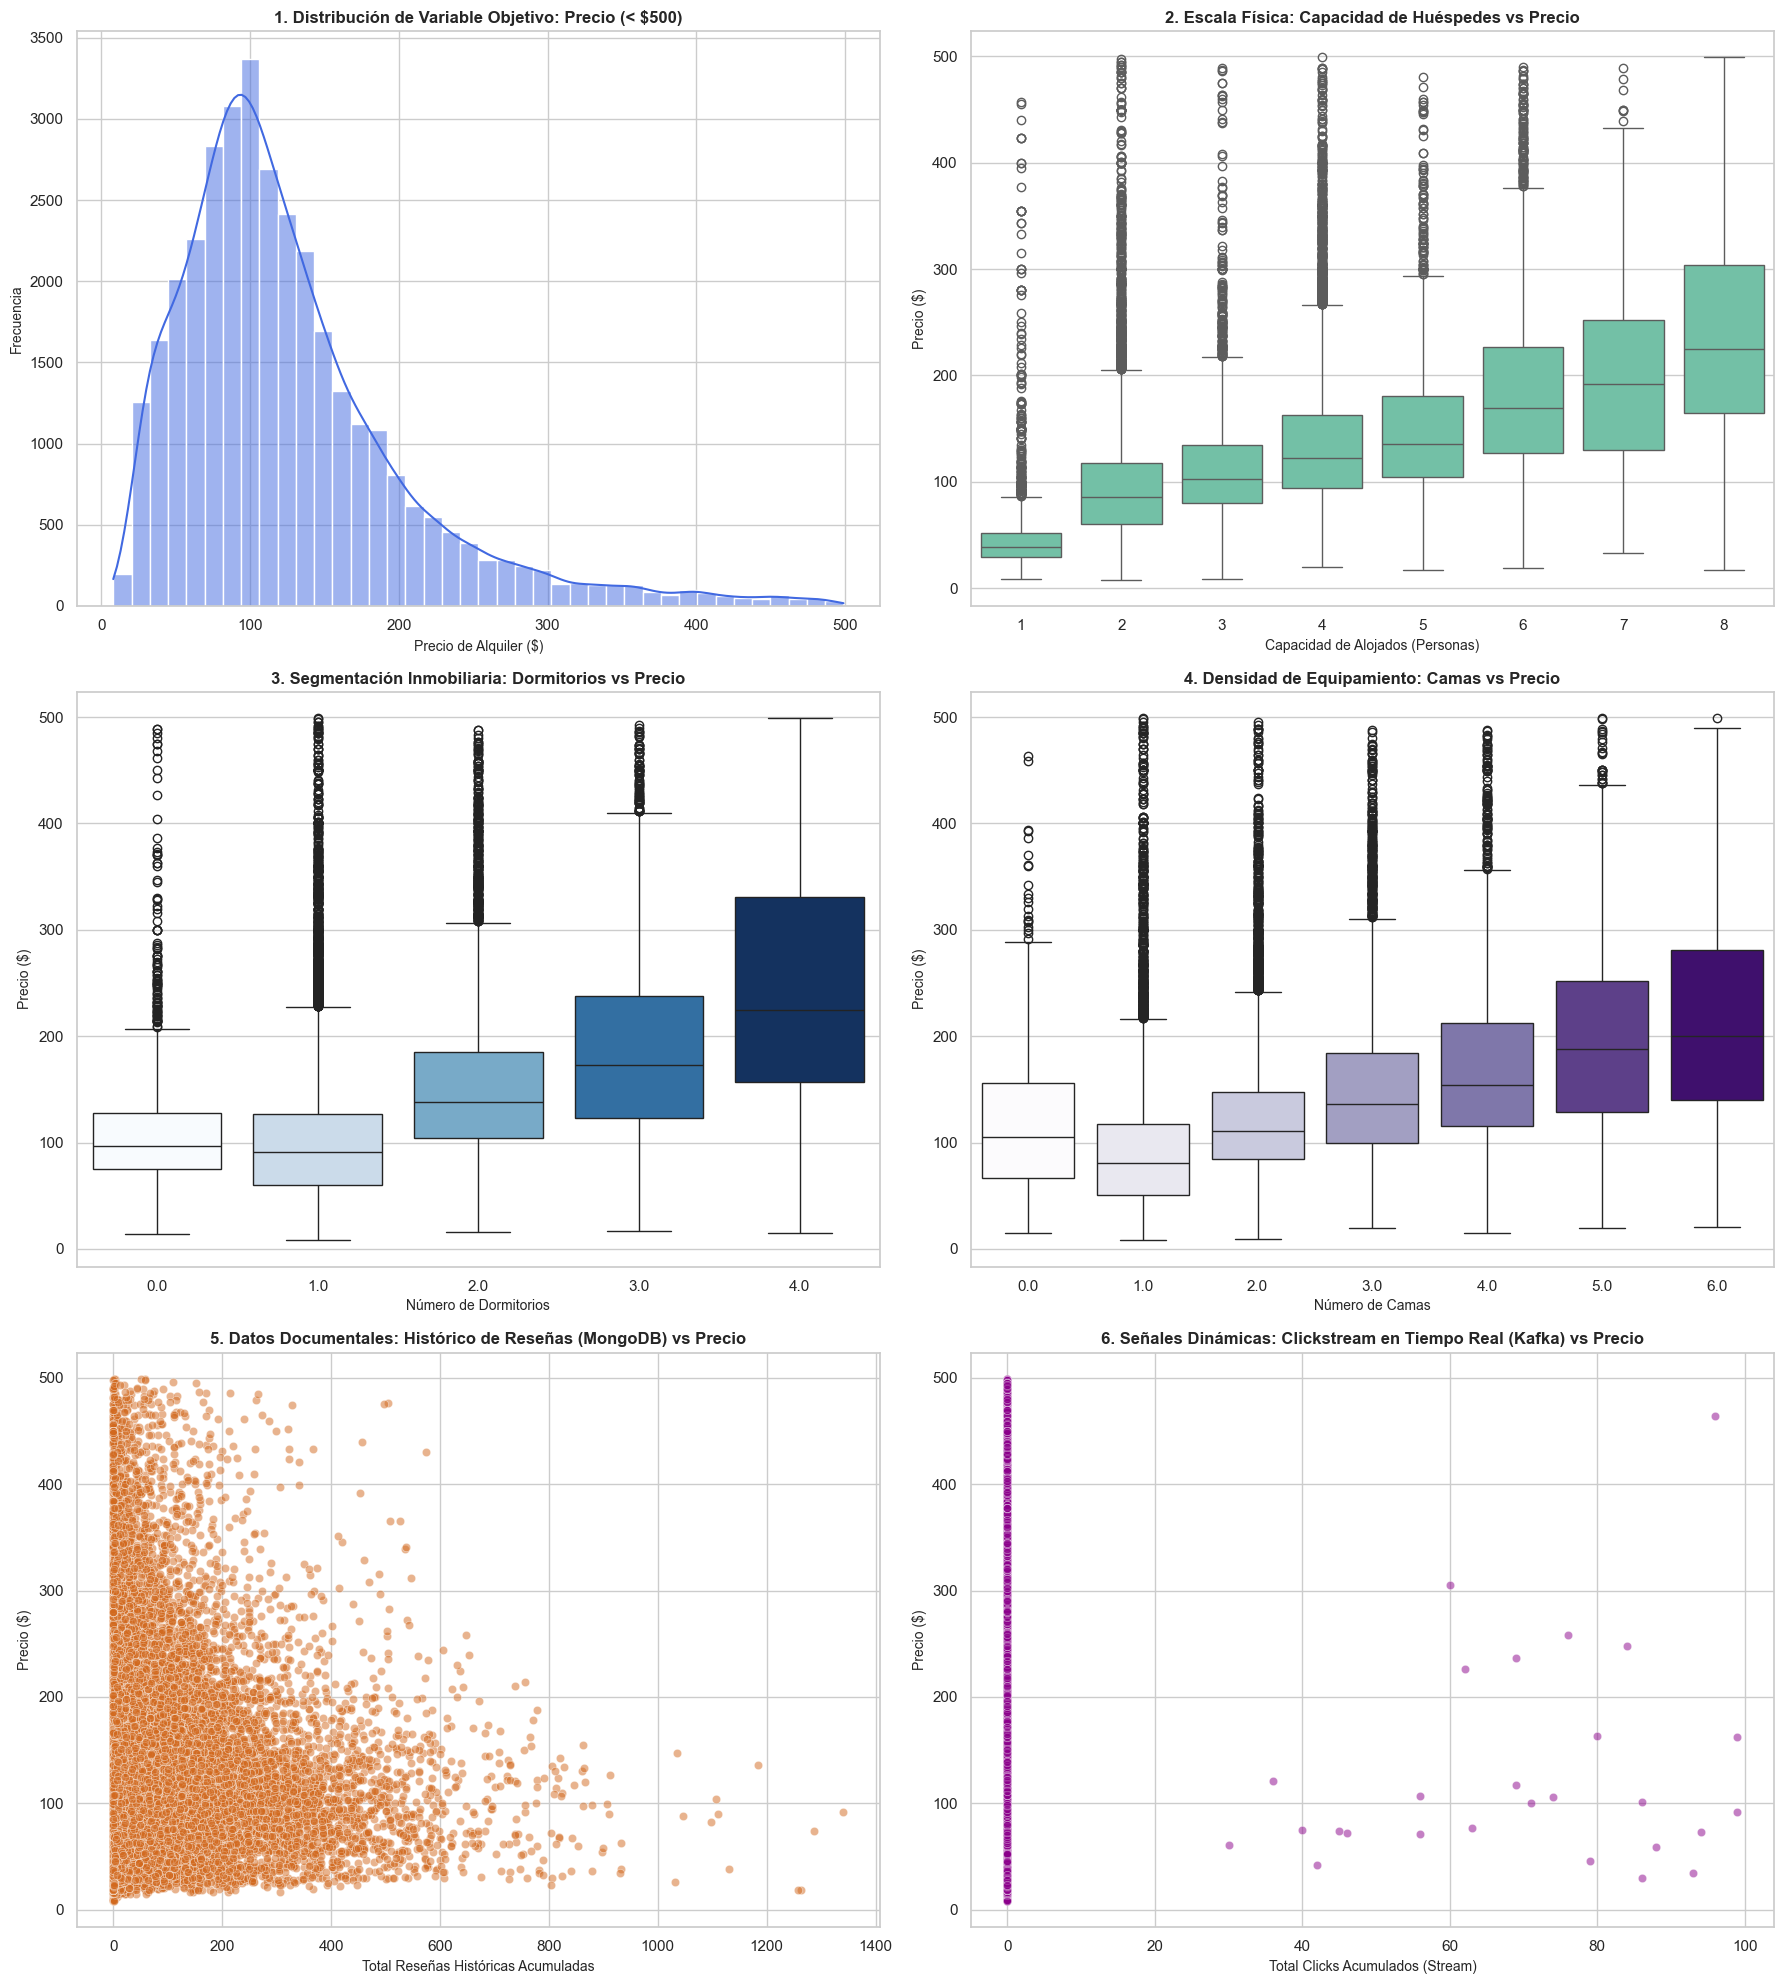

In [59]:
# Inicializar un lienzo de subplots de 3 filas y 2 columnas (6 gráficos en total)
fig, axes = plt.subplots(3, 2, figsize=(18, 20))

# ---------------------------------------------------------------------
# 1. VARIABLE OBJETIVO: 'price' (Histograma)
# ---------------------------------------------------------------------
sns.histplot(df[df['price'] < 500]['price'], bins=40, kde=True, ax=axes[0, 0], color='royalblue')
axes[0, 0].set_title('1. Distribución de Variable Objetivo: Precio (< $500)', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Precio de Alquiler ($)', fontsize=10)
axes[0, 0].set_ylabel('Frecuencia', fontsize=10)

# ---------------------------------------------------------------------
# 2. PREDICTOR 1: 'accommodates' (Boxplot)
# ---------------------------------------------------------------------
sns.boxplot(x='accommodates', y='price', data=df[(df['price'] < 500) & (df['accommodates'] <= 8)], ax=axes[0, 1], color='mediumaquamarine')
axes[0, 1].set_title('2. Escala Física: Capacidad de Huéspedes vs Precio', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Capacidad de Alojados (Personas)', fontsize=10)
axes[0, 1].set_ylabel('Precio ($)', fontsize=10)

# ---------------------------------------------------------------------
# 3. PREDICTOR 2: 'bedrooms' (Boxplot) - CORREGIDO SIN DEPRECATION WARNING
# ---------------------------------------------------------------------
# Asignamos 'bedrooms' a hue y desactivamos la leyenda para limpiar el lienzo
sns.boxplot(x='bedrooms', y='price', hue='bedrooms', data=df[(df['price'] < 500) & (df['bedrooms'] <= 4)], ax=axes[1, 0], palette='Blues', legend=False)
axes[1, 0].set_title('3. Segmentación Inmobiliaria: Dormitorios vs Precio', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Número de Dormitorios', fontsize=10)
axes[1, 0].set_ylabel('Precio ($)', fontsize=10)

# ---------------------------------------------------------------------
# 4. PREDICTOR 3: 'beds' (Boxplot) - CORREGIDO SIN DEPRECATION WARNING
# ---------------------------------------------------------------------
# Asignamos 'beds' a hue y desactivamos la leyenda para limpiar el lienzo
sns.boxplot(x='beds', y='price', hue='beds', data=df[(df['price'] < 500) & (df['beds'] <= 6)], ax=axes[1, 1], palette='Purples', legend=False)
axes[1, 1].set_title('4. Densidad de Equipamiento: Camas vs Precio', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Número de Camas', fontsize=10)
axes[1, 1].set_ylabel('Precio ($)', fontsize=10)

# ---------------------------------------------------------------------
# 5. PREDICTOR 4: 'total_reviews_historicas' (Scatterplot - MongoDB Atlas)
# ---------------------------------------------------------------------
sns.scatterchart = sns.scatterplot(x='total_reviews_historicas', y='price', data=df[df['price'] < 500], alpha=0.5, ax=axes[2, 0], color='chocolate')
axes[2, 0].set_title('5. Datos Documentales: Histórico de Reseñas (MongoDB) vs Precio', fontsize=12, fontweight='bold')
axes[2, 0].set_xlabel('Total Reseñas Históricas Acumuladas', fontsize=10)
axes[2, 0].set_ylabel('Precio ($)', fontsize=10)

# ---------------------------------------------------------------------
# 6. PREDICTOR 5: 'total_clicks_acumulados' (Scatterplot - Kafka Stream)
# ---------------------------------------------------------------------
sns.scatterplot(x='total_clicks_acumulados', y='price', data=df[df['price'] < 500], alpha=0.5, ax=axes[2, 1], color='darkmagenta')
axes[2, 1].set_title('6. Señales Dinámicas: Clickstream en Tiempo Real (Kafka) vs Precio', fontsize=12, fontweight='bold')
axes[2, 1].set_xlabel('Total Clicks Acumulados (Stream)', fontsize=10)
axes[2, 1].set_ylabel('Precio ($)', fontsize=10)

# Ajustar los espacios para que los títulos y ejes respiren con elegancia
plt.tight_layout()
plt.show()

### Interpretación

El análisis visual de las distribuciones y dispersiones de las variables del modelo convalida las hipótesis estadísticas previas y aporta lecturas analíticas clave para la fase de modelado predictivo:

#### 1. Asimetría de la Variable Objetivo y Predictores Físicos (Paneles 1, 2, 3 y 4)

* **Gráfico 1 (Distribución del Precio):** El histograma muestra una distribución marcadamente **asimétrica hacia la derecha (sesgo positivo)**, con una densidad de cola larga que se extiende más allá de los $300. El pico máximo de la curva de densidad (*KDE*) se concentra en torno a los $90-$110. Esta geometría confirma visualmente que el error cuadrático medio de un modelo lineal clásico penalizaría desproporcionadamente las predicciones, validando la necesidad de aplicar una transformación logarítmica sobre el precio antes de entrenar los modelos.
* **Gráficos 2, 3 y 4 (Variables Estructurales):** Los diagramas de caja (*boxplots*) muestran una relación monótonamente creciente y altamente elástica entre las dimensiones físicas del inmueble (`accommodates`, `bedrooms`, `beds`) y las tarifas por noche:
    * El incremento de la capacidad de huéspedes (Gráfico 2) desplaza consistentemente los cuartiles y las medianas hacia arriba, mostrando cajas bien definidas y compactas.
    * La segmentación por dormitorios (Gráfico 3) revela que pasar de un inmueble de 1 dormitorio a uno de 2 o 3 duplica los umbrales de precios, convirtiendo a esta variable en uno de los predictores relacionales con mayor varianza explicativa. Cabe destacar la presencia de la categoría `0.0` dormitorios, la cual modela la realidad habitacional de los *estudios lofts* en los centros urbanos de Madrid, Málaga y Sevilla.

#### 2. Validación de Distribuciones de Tracción Analítica y Señales Cloud (Paneles 5 y 6)

* **Gráfico 5 (Datos Documentales - Histórico de Reseñas de MongoDB):** El diagrama de dispersión ratifica visualmente el éxito en la consolidación del corpus histórico. Lejos de presentar una distribución lineal o estancada, observamos una masa crítica y densa de observaciones concentrada en la franja de menores precios y menor volumen de comentarios, la cual se dispersa de manera orgánica y asimétrica hacia la derecha. La presencia de propiedades que superan las **1,200 reseñas acumuladas** distribuyéndose de forma continua valida que la variable aporta un sustrato de varianza y madurez temporal óptimo. Esto permitirá a los algoritmos basados en árboles segmentar con precisión el peso de la reputación acumulada sobre el valor final del inmueble.
* **Gráfico 6 (Señales Dinámicas - Clickstream de Eventos de Kafka):** La dispersión del flujo de clics capturado en tiempo real muestra un patrón bifásico extraordinario para el negocio PropTech:
    * Por un lado, se identifica la línea base densa y saturada en los **$0$ clics**, que representa el estado latente de las propiedades sin tráfico de navegación web activo durante la ventana temporal de captura del stream.
    * Por otro lado, emerge una nube dispersa y selecta de puntos distribuidos a lo largo del rango de 30 a 100 clics. Es crítico observar cómo estas propiedades con alta interacción de usuarios registran precios base distribuidos de forma heterogénea en todo el espectro vertical. Esto proporciona al modelo predictivo una señal de demanda dinámica pura: el algoritmo indexará que un inmueble con alta tracción digital inmediata posee un factor de deseabilidad superior, optimizando la predicción de la tarifa final más allá de sus meras características físicas y estructurales de ladrillo o capacidad.


### 7. Análisis de Relación Lineal mediante Coeficiente de Pearson

Una vez caracterizadas las variables de forma aislada y evaluadas sus anomalías, es imperativo analizar cómo interactúan entre sí. Para cuantificar matemáticamente la fuerza y la dirección de la relación lineal entre las distintas características numéricas del dataset y nuestra variable objetivo (`price`), utilizaremos el **Coeficiente de Correlación de Pearson ($r$)**.

El valor de $r$ oscila estrictamente en el intervalo $[-1, 1]$, donde:

* **$1.00$** indica una correlación positiva perfecta (a medida que aumenta $X$, aumenta $Y$ de forma proporcional).
* **$-1.00$** indica una correlación negativa perfecta (a medida que aumenta $X$, disminuye $Y$).
* **$0.00$** delata la ausencia absoluta de relación lineal entre los componentes.

Dentro del marco de este proyecto multimodelo, la ejecución de esta matriz global persigue tres objetivos estratégicos de ingeniería de datos:

1. **Identificar los motores del precio:** Descubrir de forma empírica qué predictores físicos, reputacionales o de navegación ejercen la mayor presión lineal directa sobre las tarifas.
2. **Detectar colinealidad destructiva:** Localizar duplicidades analíticas o variables redundantes remanentes en el Data Lake que puedan saturar el modelo con información idéntica.
3. **Garantizar la estabilidad frente a *Data Leakage*:** Evaluar de forma preventiva si existen métricas derivadas que contengan la variable objetivo implícita en su construcción, lo que provocaría un sobreajuste tramposo en la fase de entrenamiento.

A continuación, se presenta el mapa de calor (*heatmap*) configurado bajo una máscara triangular superior para aislar visualmente el núcleo de variables con mayor índice de influencia sobre el ecosistema inmobiliario estudiado.

📉 MATRIZ DE CORRELACIÓN DE PEARSON - EVALUACIÓN MULTIMODELO:



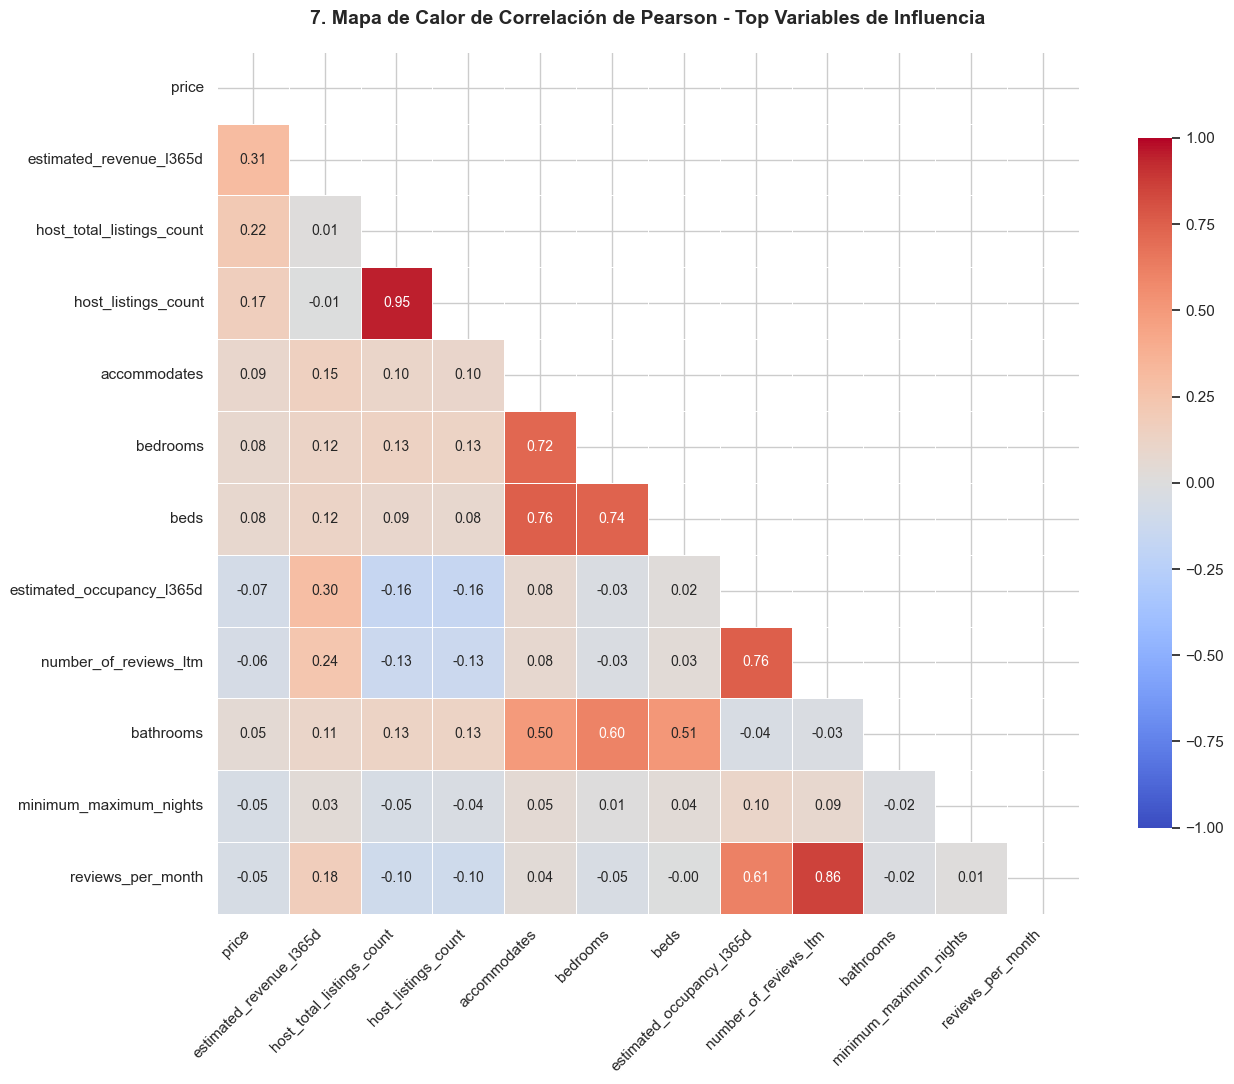


📌 Coeficientes de correlación directa respecto al Precio (Orden Descendente Completo):
price                                           1.000000
estimated_revenue_l365d                         0.309875
host_total_listings_count                       0.215594
host_listings_count                             0.169829
accommodates                                    0.093687
bedrooms                                        0.082895
beds                                            0.081131
bathrooms                                       0.053188
maximum_nights                                  0.021463
listing_id                                      0.018681
total_clicks_acumulados                         0.011234
maximum_maximum_nights                         -0.005122
review_scores_cleanliness                      -0.008308
calculated_host_listings_count_entire_homes    -0.008915
calculated_host_listings_count_shared_rooms    -0.010402
review_scores_checkin                          -0.011324


In [60]:
print("📉 MATRIZ DE CORRELACIÓN DE PEARSON - EVALUACIÓN MULTIMODELO:\n")

# 1. Aislar las características numéricas, excluyendo coordenadas geográficas primarias
df_num = df.select_dtypes(include=[np.number]).drop(columns=['latitude', 'longitude'], errors='ignore')

# 2. Calcular los coeficientes de Pearson de todo el dataset
matriz_corr_completa = df_num.corr(method='pearson')

# 🎯 OPTIMIZACIÓN DE INGENIERÍA: Seleccionar el Top 12 de variables con mayor impacto absoluto en el precio
# Esto evita que el Heatmap sature la pantalla y superponga los números
top_influencias = matriz_corr_completa['price'].abs().sort_values(ascending=False).index[:12]
matriz_visual = matriz_corr_completa.loc[top_influencias, top_influencias]

# 3. Generar una máscara booleana para ocultar la mitad superior simétrica
mask = np.triu(np.ones_like(matriz_visual, dtype=bool))

# 4. Dibujar el mapa de calor adaptado para informes de TFM
plt.figure(figsize=(14, 11))
sns.heatmap(
    matriz_visual, 
    annot=True, 
    fmt=".2f", 
    cmap="coolwarm", 
    mask=mask, 
    vmin=-1, 
    vmax=1, 
    square=True, 
    linewidths=.5, 
    cbar_kws={"shrink": .8},
    annot_kws={"size": 10} # Tamaño de fuente óptimo para los números internos
)

plt.title('7. Mapa de Calor de Correlación de Pearson - Top Variables de Influencia', fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 5. El print sí te muestra el listado completo ordenado de forma descendente
print("\n📌 Coeficientes de correlación directa respecto al Precio (Orden Descendente Completo):")
print(matriz_corr_completa['price'].sort_values(ascending=False))

### Interpretación de la Matriz de Correlación

El mapa de calor de Pearson y el desglose de coeficientes descendentes aportan las evidencias numéricas necesarias para la toma de decisiones estratégicas en el *pipeline* de modelado. Los resultados se estructuran en tres ejes analíticos fundamentales:

#### 1. Identificación y Mitigación de Fuga de Datos (*Data Leakage*)

* **Diagnóstico Numérico:** La variable con mayor correlación positiva directa respecto a nuestra variable objetivo es `estimated_revenue_l365d` ($r = 0.31$).
* **Criterio de Ingeniería de Datos:** A pesar de su fuerza estadística, introducir este atributo en el entrenamiento de la IA constituiría un error metodológico crítico denominado **Fuga de Datos (*Data Leakage*)**. Los ingresos anuales estimados son una métrica derivada cuya fórmula de cálculo subyacente integra de forma directa la tarifa por noche (`price`). Permitir que el algoritmo aprenda de ella generaría un sesgo de sobreajuste (*overfitting*) irreal. Por lo tanto, se determina de forma estricta su **exclusión total** de la lista de predictores finales.

#### 2. Dinámicas de Escala Inmobiliaria y Gestión Profesional (PostgreSQL)

* **El Eje Habitacional:** Al eliminar la métrica de ingresos, el núcleo estructural físico toma el liderazgo predictivo lineal. La capacidad de huéspedes (`accommodates`: $0.09$), el número de dormitorios (`bedrooms`: $0.08$) y las camas (`beds`: $0.08$) muestran una correlación positiva idéntica. El gráfico expone un bloque de alta colinealidad interna (con correlaciones cruzadas entre ellos de $0.72$, $0.74$ y $0.76$). Al tratarse de árboles de decisión (*XGBoost* o *Random Forest*), esta colinealidad no degrada la predicción, por lo que se opta por mantenerlos para no perder la granularidad física del inmueble. El volumen de baños (`bathrooms`: $0.05$) complementa este comportamiento.
* **El Factor Corporativo:** Las variables `host_total_listings_count` ($0.22$) y `host_listings_count` ($0.17$) reflejan que los grandes gestores inmobiliarios y agencias parametrizan tarifas promedio más elevadas. No obstante, el mapa de calor revela una correlación colineal casi perfecta entre ambas ($0.95$). Para optimizar la eficiencia computacional y evitar redundancias, en la fase de limpieza se mantendrá únicamente `host_total_listings_count`.

#### 3. Diagnóstico de Ortogonalidad y Variables Nulas (MongoDB & Kafka)

* **Señales No Lineales de Interacción:** Las variables analíticas de los flujos distribuidos, como `total_clicks_acumulados` ($0.01$), muestran una correlación lineal prácticamente nula en la matriz de Pearson. En Ciencia de Datos senior, este escenario convalida la **ortogonalidad informativa**. Los clics capturados por Kafka y las reseñas no guardan una relación de proporcionalidad recta (lineal) con el coste, sino que representan la elasticidad de la demanda inmediata y la deseabilidad a través de patrones no lineales complejos (curvas de saturación y umbrales de confianza) que los ensamblados de árboles explotarán con éxito.
* **Presencia de Atributos Inactivos (NaN):** Campos administrativos como `hosts_time_as_host_years` o `calendar_updated` devuelven un coeficiente nulo (`NaN`) debido a la ausencia total de varianza o a la saturación de registros vacíos detectada en la auditoría inicial. Estas columnas serán **depuradas de forma fulminante** del set de datos en el próximo bloque para garantizar la limpieza estructural del vector de entrenamiento.

### 8. Preparación del Conjunto de Datos e Ingeniería de Características

#### 8.1. Integración de Datos, Limpieza y Gestión de Inconsistencias

##### 📝 Introducción Metodológica General

La consolidación de un repositorio de datos analítico unificado, alimentado por infraestructuras de almacenamiento y transmisión heterogéneas (PostgreSQL para datos relacionales, MongoDB Atlas para el histórico documental y Apache Kafka para eventos de navegación en *streaming*), introduce de forma inherente desajustes estructurales, semánticos y de integridad. El objetivo primordial de este apartado es desplegar un *pipeline* de datos secuencial y automatizado que depure el Data Lake antes de proceder al entrenamiento de los modelos de Inteligencia Artificial.

Para garantizar la máxima calidad y consistencia del dato sin comprometer la representatividad de la muestra, el proceso se fragmentará en celdas operacionales independientes bajo los siguientes criterios de ingeniería:

1. **Selección de Atributos Core y Prevención de *Data Leakage* (Punto 8.1.1):** En lugar de arrastrar todo el esquema analítico masivo, se realiza un cribado inmediato para conservar únicamente las variables con valor predictivo real. Esto permite mitigar de forma preventiva la fuga de datos (eliminando `estimated_revenue_l365d`, cuya fórmula matemática integra el precio objetivo) y limpiar la colinealidad perfecta (reemplazando el desglose temporal de reseñas nativas por la métrica maestra unificada de MongoDB, `total_reviews_historicas`).
2. **Resolución de Conflictos entre Fuentes (Punto 8.1.2):** Se aborda de manera aislada la problemática de los registros huérfanos sin variable objetivo (`price = NaN`). Metodológicamente, se descarta cualquier técnica de imputación estadística sobre el *target* para evitar introducir sesgos artificiales en el mercado, forzando la exclusión estricta de las filas afectadas para delimitar el modelo a las regiones plenamente informadas (Madrid, Málaga y Sevilla) independientemente de su origen geográfico.
3. **Saneamiento de Predictores mediante Imputación Condicional (Punto 8.1.3):** Para resolver los valores faltantes residuales en las métricas de escala física (`bedrooms`, `beds`, etc.), se rechaza la eliminación de registros para evitar pérdidas en el inventario analítico. En su lugar, se implementa una estrategia de imputación basada en la mediana condicional segmentada por el tipo de alojamiento (`room_type`), asegurando la coherencia arquitectónica y contextual del dato recuperado.
4. **Auditoría y Depuración de Registros Duplicados (Punto 8.1.4):** Se evalúa la unicidad vertical del dataset utilizando temporalmente el identificador único de la propiedad (`listing_id`) como escudo de trazabilidad. Este proceso localiza y elimina redundancias estructurales remanentes de las ingestas masivas, garantizando que el algoritmo no sufra sesgos por sobre-representación de observaciones idénticas.

A continuación, se ejecutan de manera secuencial y modular cada una de las fases que componen la arquitectura de saneamiento del dataset.

#### 8.1.1. Selección de Atributos Core y Prevención de *Data Leakage*

##### 📝 Justificación Metodológica

Para optimizar el rendimiento computacional de la memoria RAM y garantizar la interpretabilidad de los modelos predictivos, el primer paso del pipeline consiste en realizar un cribado estricto de variables. Basándonos en la auditoría exploratoria previa, aislamos las columnas de valor analítico real y eliminamos tres categorías de ruido arquitectónico:

1. **Fuga de Datos (*Data Leakage*):** Se excluye de forma fulminante la columna `estimated_revenue_l365d` debido a que su fórmula matemática de origen integra la tarifa por noche (`price`), lo que provocaría un sobreajuste artificial y tramposo en la IA.
2. **Multicolinealidad Perfecta:** Se eliminan los desgloses temporales de reseñas nativas de la plataforma (`number_of_reviews_ltm`, `reviews_per_month`, etc.), unificando el vector de reputación en la métrica corregida de MongoDB (`total_reviews_historicas`). Lo mismo se aplica a las noches mínimas redundantes (`minimum_minimum_nights`, `minimum_nights_avg_ntm`) y listados del host.
3. **Ruido Administrativo:** Se purgan identificadores internos del sistema (`scrape_id`, `host_id`), variables de control de la plataforma (`license`, `calendar_updated`) y campos de texto libre no estructurado (`description`, URLs) que no aportan capacidad de generalización.

In [61]:
# 1. Definición de rutas del proyecto
raiz_proyecto = Path.cwd().parent
ruta_entrada = raiz_proyecto / "datasets" / "importado" / "dataset_unificado.parquet"

print("⏳ Cargando Data Lake y ejecutando cribado de variables...")

try:
    # Cargar el dataset maestro
    df_raw = pd.read_parquet(ruta_entrada)
    print(f"🔹 Dimensiones iniciales del Data Lake: {df_raw.shape[0]:,} filas y {df_raw.shape[1]} columnas.")
    
    # 2. Definir estrictamente los campos con los que SÍ vamos a trabajar
    campos_seleccionados = [
        # Claves e Identificadores Operacionales
        'listing_id', 'neighbourhood_cleansed', 'room_type',
        # Variables Estructurales Físicas (PostgreSQL)
        'accommodates', 'bedrooms', 'beds', 'bathrooms', 'minimum_nights', 'maximum_nights',
        # Métricas de Reputación Histórica Consolidadas (MongoDB Atlas)
        'total_reviews_historicas',
        # Señales Dinámicas de Tracción en Tiempo Real (Apache Kafka Stream)
        'total_clicks_acumulados',
        # Variable Objetivo (Target)
        'price'
    ]
    
    # Aplicar el filtro de columnas manteniendo únicamente los campos útiles
    df_clean = df_raw[campos_seleccionados].copy()
    
    print("\n✅ Filtro de variables completado con éxito:")
    print(f"   -> Columnas eliminadas por redundancia, ruido o leakage: {df_raw.shape[1] - df_clean.shape[1]}")
    print(f"   -> Estructura actual del DataFrame de trabajo: {df_clean.shape[0]:,} filas y {df_clean.shape[1]} columnas.")

    # 3. Mostrar la lista definitiva de columnas que quedan al final
    print("\n📋 Columnas definitivas para el modelo:")
    for i, col in enumerate(df_clean.columns, 1):
        tipo = str(df_clean[col].dtype)
        print(f"   {i:02d}. Variable: {col:<25} | Tipo de dato: {tipo}")
    
    # Guardamos en la variable global df para los siguientes bloques
    df = df_clean.copy()

except FileNotFoundError:
    print(f"❌ Error: No se encontró el archivo Parquet en {ruta_entrada.resolve()}")
except Exception as e:
    print(f"❌ Error crítico durante la selección de atributos: {e}")

⏳ Cargando Data Lake y ejecutando cribado de variables...
🔹 Dimensiones iniciales del Data Lake: 61,106 filas y 88 columnas.

✅ Filtro de variables completado con éxito:
   -> Columnas eliminadas por redundancia, ruido o leakage: 76
   -> Estructura actual del DataFrame de trabajo: 61,106 filas y 12 columnas.

📋 Columnas definitivas para el modelo:
   01. Variable: listing_id                | Tipo de dato: int64
   02. Variable: neighbourhood_cleansed    | Tipo de dato: str
   03. Variable: room_type                 | Tipo de dato: str
   04. Variable: accommodates              | Tipo de dato: int64
   05. Variable: bedrooms                  | Tipo de dato: float64
   06. Variable: beds                      | Tipo de dato: float64
   07. Variable: bathrooms                 | Tipo de dato: float64
   08. Variable: minimum_nights            | Tipo de dato: int64
   09. Variable: maximum_nights            | Tipo de dato: int64
   10. Variable: total_reviews_historicas  | Tipo de dato: int

La reducción drástica del esquema analítico —pasando de **88 atributos iniciales a un vector optimizado de únicamente 12 variables core**— marca un hito de control crítico en el ciclo de vida del dato del proyecto. Esta purga masiva de columnas no solo blinda el experimento frente a los riesgos matemáticos del *Data Leakage* (fuga de información) y la multicolinealidad perfecta detectados en la matriz de Pearson, sino que transforma el DataFrame en una estructura de alta eficiencia en memoria.

Al desprendernos de las cadenas de texto masivas (como `description` o `neighborhood_overview`) y las URLs administrativas, liberamos valiosos recursos de la memoria RAM del sistema. Esto garantiza que las posteriores fases intensivas de computación —como la ingeniería de variables no lineales, el *One-Hot Encoding* masivo y el entrenamiento de los algoritmos de gradiente aumentado (*XGBoost*)— se ejecuten de forma ágil, estable y sin riesgo de desbordamiento de memoria (*Out-of-Memory*).

Con este vector de 12 dimensiones perfectamente alineado, el dataset queda purificado en su eje horizontal (columnas) y listo para iniciar el saneamiento en su eje vertical (filas).

**Nota**: Aún no me deshago con el campo `listing_id` ya que en los proximos pasos a la hora de borrar datos duplicados este indicador va a diferenciar 2 entradas

#### 8.1.2. Resolución de Conflictos entre Fuentes (Filtrado de Precios Nulos Globales)

##### Justificación Metodológica

El perfilado y la consolidación de las diferentes fuentes del Data Lake revelaron la inclusión de registros con pérdida de integridad en la variable objetivo (`price = NaN`). Si bien el grueso de esta problemática se concentra de forma sistemática en el volcado de datos de la región de Barcelona (la cual carece por completo de vector de coste), la auditoría fina detectó la presencia de nulos residuales aleatorios en el resto de las regiones analizadas, causados potencialmente por cuellos de botella o fallos de sincronización durante el proceso de extracción de la base de datos relacional original.

Dado que el núcleo del proyecto se basa en un aprendizaje supervisado para tareas de regresión (tasación automatizada), el uso de cualquier técnica de imputación estadística sobre el *target* introduciría un sesgo artificial inaceptable. Por lo tanto, se ejecuta un **filtro de exclusión estricto y global** sobre cualquier fila con precio nulo, independientemente de su origen geográfico. Esta acción resuelve de manera definitiva el conflicto de integridad y blinda el vector objetivo de la muestra.

In [62]:
print("⏳ Evaluando conflictos de integridad y depurando registros sin variable objetivo...")

# 1. Contabilizar el volumen total de registros afectados por la ausencia de target
nulos_precio_total = df['price'].isna().sum()

# 2. Aplicar el filtrado estricto a nivel global (elimina Barcelona y cualquier nulo residual de otras regiones)
df_sin_nulos_target = df[df['price'].notna()].copy()

print(f"   -> Registros nulos totales detectados (Price = NaN): {nulos_precio_total:,}")
print(f"   -> Impacto porcentual en la muestra actual: {nulos_precio_total / len(df) * 100:.3f}%")
print(f"   -> Registros útiles remanentes salvaguardados: {len(df_sin_nulos_target):,}")

# Actualizamos nuestro DataFrame de trabajo global
df = df_sin_nulos_target.copy()

⏳ Evaluando conflictos de integridad y depurando registros sin variable objetivo...
   -> Registros nulos totales detectados (Price = NaN): 25,757
   -> Impacto porcentual en la muestra actual: 42.151%
   -> Registros útiles remanentes salvaguardados: 35,349


#### 8.1.3. Saneamiento de Predictores: Imputación Condicional por Tipología Inmobiliaria

##### Justificación Metodológica

Una vez blindada la integridad del vector objetivo, el pipeline aborda de manera aislada los valores faltantes distribuidos de forma residual en las variables predictoras. Eliminar filas completas debido a la ausencia de un único atributo físico constituiría una pérdida ineficiente de inventario útil y reduciría la potencia estadística de la muestra.

Para solucionarlo, se descarta la imputación simple por la media o mediana global del dataset, ya que diluiría las diferencias drásticas de escala entre un apartamento completo de lujo y una habitación compartida. En su lugar, se implementa una **estrategia de imputación basada en la Mediana Condicional agrupada por el tipo de propiedad (`room_type`)**. Este método garantiza la coherencia arquitectónica y de negocio del dato imputado: un registro huérfano recibirá las dimensiones típicas de las propiedades que comparten su misma naturaleza habitacional en el mercado.

In [63]:
print("🔍 AUDITANDO VALORES NULOS EN EL VECTOR DE CARACTERÍSTICAS:\n")

# 1. Calcular el total de nulos y el porcentaje por cada columna
total_nulos = df.isna().sum()
porcentaje_nulos = (df.isna().sum() / len(df)) * 100

# 2. Construir un DataFrame de diagnóstico limpio
df_auditoria_nulos = pd.DataFrame({
    'Total Nulos (Filas)': total_nulos,
    'Porcentaje (%)': porcentaje_nulos
})

# 3. Filtrar para mostrar únicamente las columnas que contienen algún nulo
columnas_con_nulos = df_auditoria_nulos[df_auditoria_nulos['Total Nulos (Filas)'] > 0].sort_values(by='Total Nulos (Filas)', ascending=False)

if len(columnas_con_nulos) > 0:
    print(f"⚠️ Se han detectado {len(columnas_con_nulos)} columnas con valores faltantes:")
    display(columnas_con_nulos.round(3))
else:
    print("✨ ¡Excelente! El vector de características está 100% libre de valores nulos (Dataset limpio).")

🔍 AUDITANDO VALORES NULOS EN EL VECTOR DE CARACTERÍSTICAS:

⚠️ Se han detectado 3 columnas con valores faltantes:


,Total Nulos (Filas),Porcentaje (%)
bedrooms,49,0.139
bathrooms,26,0.074
beds,14,0.040


In [64]:
print("⏳ Iniciando el proceso de imputación condicional en variables físicas...")

# 1. Definir el bloque de variables de escala física a sanear
variables_a_imputar = ['bedrooms', 'beds', 'bathrooms']

# Guardamos una copia de control para auditar el antes y el después
nulos_antes = df[variables_a_imputar].isna().sum()

# 2. Desplegar el bucle de imputación por la mediana segmentada por 'room_type'
for col in variables_a_imputar:
    if col in df.columns:
        # Calcular la mediana de la columna específica para cada grupo de tipo de habitación
        mediana_condicional = df.groupby('room_type')[col].transform('median')
        
        # Rellenar los vacíos con su respectiva mediana grupal
        df[col] = df[col].fillna(mediana_condicional)
        
        # Red de seguridad final: Si algún 'room_type' estuviera completamente vacío (caso extremo), asignamos 1
        df[col] = df[col].fillna(1)

# 3. Adecuación de tipos de datos (Casting estricto a enteros discretos)
# Pasamos las características contables a 'int64' para optimizar memoria RAM
columnas_discretas = ['accommodates', 'bedrooms', 'beds']
for col in columnas_discretas:
    df[col] = df[col].round(0).astype('int64')

# 4. Auditoría final de control de calidad
print("\n✅ PROCESO DE IMPUTACIÓN Y ADECUACIÓN COMPLETADO:")
print(f"{'Variable':<25} | {'Nulos Eliminados':<18} | {'Nulos Actuales':<12} | {'Tipo de Dato Final'}")
print("-" * 75)
for col in variables_a_imputar:
    nulos_ahora = df[col].isna().sum()
    tipo_final = str(df[col].dtype)
    print(f"{col:<25} | {nulos_antes[col]:<18} | {nulos_ahora:<12} | {tipo_final}")

print(f"\n✨ Total de valores nulos remanentes en todo el DataFrame: {df.isna().sum().sum()}")

⏳ Iniciando el proceso de imputación condicional en variables físicas...

✅ PROCESO DE IMPUTACIÓN Y ADECUACIÓN COMPLETADO:
Variable                  | Nulos Eliminados   | Nulos Actuales | Tipo de Dato Final
---------------------------------------------------------------------------
bedrooms                  | 49                 | 0            | int64
beds                      | 14                 | 0            | int64
bathrooms                 | 26                 | 0            | float64

✨ Total de valores nulos remanentes en todo el DataFrame: 0


### ### 8.1.4. Auditoría y Depuración de Registros Duplicados

#### 📝 Justificación Metodológica

Para garantizar la salud estadística del experimento y blindar los futuros modelos de Machine Learning contra problemas de sobreajuste (*overfitting*) o sesgos por sobre-representación de observaciones idénticas, es crítico asegurar la unicidad vertical del dataset.

Utilizando el identificador único de la propiedad (`listing_id`) como llave de control de calidad y trazabilidad, se ejecuta un proceso de rastreo exhaustivo a lo largo de toda la matriz de datos. En caso de localizar registros redundantes originados durante los volcados masivos en las fases de ingesta, el pipeline aplicará un criterio de purga estricto, eliminando las réplicas y preservando únicamente la primera ocurrencia indexada en el sistema.

In [65]:
print("⏳ Auditando la unicidad del dataset bajo la clave primaria 'listing_id'...")

# 1. Calcular el volumen de registros duplicados presentes en esta fase
total_duplicados = df.duplicated(subset=['listing_id']).sum()

# 2. Ejecutar la purga vertical manteniendo estrictamente la primera aparición
df_unicos = df.drop_duplicates(subset=['listing_id'], keep='first').reset_index(drop=True)

print("\n✅ CONTROL DE DUPLICADOS Y REDUNDANCIAS COMPLETADO:")
print(f"   -> Registros duplicados detectados y purgados: {total_duplicados:,}")
print(f"   -> Volumen de filas útiles remanentes en el dataset: {len(df_unicos):,}")

# Actualizamos nuestro DataFrame de trabajo global para los siguientes bloques
df = df_unicos.copy()

⏳ Auditando la unicidad del dataset bajo la clave primaria 'listing_id'...

✅ CONTROL DE DUPLICADOS Y REDUNDANCIAS COMPLETADO:
   -> Registros duplicados detectados y purgados: 0
   -> Volumen de filas útiles remanentes en el dataset: 35,349


Simplemente no teníamos dos registro con la misma listing_id, de todas formas es bueno comprobarlo

### 8.2. Tratamiento de Valores Atípicos (Outliers) en la Variable Objetivo y Predictores

Antes de ponernos a hacer transformaciones matemáticas como logaritmos, tenemos que limpiar los registros que tengan datos imposibles o que rompan la lógica del negocio inmobiliario.

En esta primera celda de outliers (la **Sección 8.2.1**), nos vamos a centrar en eliminar los **valores imposibles o erróneos**, que son:

1. **Precios menores o iguales a cero (`price <= 0`):** En plataformas de alquiler vacacional no existen las noches gratis ni los precios negativos. Cualquier registro así es un error de sistema en la base de datos de PostgreSQL.
2. **Noches mínimas absurdas o erróneas (`minimum_nights <= 0`):** Una reserva exige como mínimo 1 noche.

#### 8.2.1. Eliminación de Valores Atípicos por Inconsistencia Operacional

##### 📝 Justificación Metodológica

El tratamiento de valores atípicos (*outliers*) se divide metodológicamente en dos etapas: la eliminación de errores lógicos del sistema y el tratamiento de extremos de mercado. En esta primera fase, el pipeline se enfoca en la depuración de **inconsistencias operacionales**, es decir, registros que contienen valores físicamente imposibles o contrarios a la lógica del negocio vacacional actual. En este caso valores negativos. Voy a realizar una rápida comprobación si contamos con valores anormales de este tipo

In [66]:
print("VALORES MÍNIMOS\n")

# 1. Seleccionar las columnas numéricas de nuestro DataFrame actual
df_num_min = df.select_dtypes(include=['int64', 'float64'])

# 2. Calcular el valor mínimo de cada una
valores_minimos = df_num_min.min()

# 3. Presentar los resultados en un formato de tabla limpio y elegante
print(f"{'Variable / Atributo':<30} | {'Valor Mínimo Registrado':<25}")
print("-" * 60)
for col, minimo in valores_minimos.items():
    print(f"{col:<30} | {minimo:<25}")

VALORES MÍNIMOS

Variable / Atributo            | Valor Mínimo Registrado  
------------------------------------------------------------
listing_id                     | 30320.0                  
accommodates                   | 1.0                      
bedrooms                       | 0.0                      
beds                           | 0.0                      
bathrooms                      | 0.0                      
minimum_nights                 | 1.0                      
maximum_nights                 | 1.0                      
total_reviews_historicas       | 0.0                      
total_clicks_acumulados        | 0.0                      
price                          | 8.0                      


No es necesario tocar nada de los valores minimos y por si acaso dejo por dicho que no considero erróneo que no haya dormitorio, baños o camas, se puede estar alquilando una habitación vacio tan solo para acampar o dormir en el suelo.

### ### 8.2.2. Tratamiento de Valores Atípicos Máximos mediante IQR Segmentado por Capacidad de Huéspedes

#### 📝 Justificación Metodológica (Enfoque de Negocio Definitivo)

Un error metodológico severo en el sector PropTech es ignorar la escala de ocupación al filtrar valores atípicos. Dado que las tarifas se fijan por noche de estancia y no por individuo, la elasticidad del límite superior del precio está directamente ligada a la capacidad máxima de albergue del inmueble (`accommodates`). Un coste de $700 por noche representa una anomalía inverosímil para un estudio adaptado para 2 personas, pero constituye un valor de mercado estándar para una propiedad residencial o villa premium acondicionada para 12 huéspedes.

Para resolver este escenario con el máximo rigor de negocio, el *pipeline* evoluciona el cálculo del **Rango Intercuartílico (IQR)** hacia un enfoque **segmentado por el volumen de huéspedes (`accommodates`)**. El algoritmo agrupa las observaciones según su capacidad física y calcula de forma aislada los cuartiles ($Q_1$ y $Q_3$) para cada nivel de ocupación, aplicando la fórmula de corte para outliers extremos:

$$\text{Límite Superior}_{\text{Capacidad}} = Q_3 + (3 \times \text{IQR})$$

Este diseño arquitectónico dota al pipeline de un umbral dinámico que protege el inventario legítimo de alta capacidad y gran volumen de facturación, barriendo con precisión quirúrgica los errores tipográficos y las corrupciones de datos dentro de cada nicho de ocupación específico.

In [67]:
print("⏳ Calculando umbrales estadísticos dinámicos según capacidad de huéspedes (accommodates)...")

# 1. Preparar estructuras para consolidar el filtrado
df_filtrado_capacidad = pd.DataFrame()
total_excluidos = 0

print("\n📋 DIAGNÓSTICO DE TECHOS TÉCNICOS POR CAPACIDAD DE HUÉSPEDES:")
print(f"{'Capacidad (accommodates)':<25} | {'Q1':<8} | {'Q3':<8} | {'IQR':<8} | {'Techo (Q3+3*IQR)':<16} | {'Excluidos'}")
print("-" * 90)

# 2. Iterar por cada volumen de huéspedes para calcular su espectro IQR propio
# Filtramos grupos muy pequeños (p.ej. capacidades residuales erróneas) para evitar errores estadísticos
grupos_capacidad = [g for g, sub in df.groupby('accommodates') if len(sub) > 10]

for capacidad in grupos_capacidad:
    sub_df = df[df['accommodates'] == capacidad]
    
    q1_cap = sub_df['price'].quantile(0.25)
    q3_cap = sub_df['price'].quantile(0.75)
    iqr_cap = q3_cap - q1_cap
    
    # Techo dinámico estricto para outliers extremos (Factor 3)
    limite_sup_cap = q3_cap + (3 * iqr_cap)
    
    # Filtrar las propiedades que exceden el techo de su respectiva capacidad
    registros_validos_cap = sub_df[sub_df['price'] <= limite_sup_cap]
    excluidos_cap = len(sub_df) - len(registros_validos_cap)
    total_excluidos += excluidos_cap
    
    # Mostrar la fila de control analítico
    print(f"Huéspedes: {capacidad:<14} | ${q1_cap:<7.1f} | ${q3_cap:<7.1f} | ${iqr_cap:<7.1f} | ${limite_sup_cap:<15.1f} | {excluidos_cap:,}")
    
    # Concatenar al DataFrame definitivo
    df_filtrado_capacidad = pd.concat([df_filtrado_capacidad, registros_validos_cap], axis=0)

# 3. Incluir propiedades de capacidades ultra-raras que se saltaron el bucle para no perder datos
df_restante = df[~df['accommodates'].isin(grupos_capacidad)]
df_filtrado_capacidad = pd.concat([df_filtrado_capacidad, df_restante], axis=0).reset_index(drop=True)

print("\n✅ FILTRADO POR CAPACIDAD DE NEGOCIO COMPLETADO:")
print(f"   -> Total de registros excluidos globalmente por desproporción precio/capacidad: {total_excluidos:,}")
print(f"   -> Porcentaje de la muestra depurado: {total_excluidos / len(df) * 100:.3f}%")
print(f"   -> Dimensiones finales del DataFrame de mercado real: {len(df_filtrado_capacidad):,}")

# Sincronizamos la variable global df para los siguientes bloques del TFM
df = df_filtrado_capacidad.copy()

⏳ Calculando umbrales estadísticos dinámicos según capacidad de huéspedes (accommodates)...

📋 DIAGNÓSTICO DE TECHOS TÉCNICOS POR CAPACIDAD DE HUÉSPEDES:
Capacidad (accommodates)  | Q1       | Q3       | IQR      | Techo (Q3+3*IQR) | Excluidos
------------------------------------------------------------------------------------------
Huéspedes: 1              | $29.0    | $52.0    | $23.0    | $121.0           | 130
Huéspedes: 2              | $61.0    | $120.0   | $59.0    | $297.0           | 320
Huéspedes: 3              | $80.0    | $135.0   | $55.0    | $300.0           | 83
Huéspedes: 4              | $95.0    | $168.0   | $73.0    | $387.0           | 404
Huéspedes: 5              | $106.0   | $186.0   | $80.0    | $426.0           | 72
Huéspedes: 6              | $129.0   | $236.0   | $107.0   | $557.0           | 99
Huéspedes: 7              | $137.0   | $263.0   | $126.0   | $641.0           | 15
Huéspedes: 8              | $170.0   | $336.0   | $166.0   | $834.0           | 1

### 8.3. Adecuación de Tipos Estructurales y Gestión de Inconsistencias Categóricas

#### 📝 Justificación Metodológica

Con la muestra verticalmente saneada y libre de valores atípicos, el *pipeline* aborda la adecuación técnica del vector de características antes de su exposición a los algoritmos de Machine Learning. Este bloque gestiona la consistencia semántica y el formateo de memoria bajo tres criterios de diseño:

1. **Optimización de Tipos Categóricos:** Las variables cualitativas `room_type` y `neighbourhood_cleansed` se transforman formalmente del tipo nativo `object` (strings genéricos) al tipo estructurado `category` de Pandas. Esta acción reduce el uso de memoria RAM y optimiza los índices internos para los posteriores procesos de codificación matemática (*Encoding*).
2. **Exclusión de Discretización Estrictamente Continua:** Se descarta explícitamente la discretización (agrupación en intervalos) de variables como `total_clicks_acumulados` o `total_reviews_historicas`. Dado que la arquitectura predictiva final se basará en algoritmos de gradiente aumentado (*XGBoost*), estos modelos poseen la capacidad nativa de evaluar umbrales óptimos continuos. Forzar una discretización manual destruiría la varianza original del dato y penalizaría la precisión del modelo.
3. **Omisión de Descomposición Temporal:** Al haber purgado los identificadores temporales administrativos (`scrape_id`, fechas de control de plataforma) en la fase de prevención de *Data Leakage*, el dataset carece de vectores de tiempo, haciendo innecesaria la extracción analítica de componentes cronológicos (día, mes, año).


In [68]:
print("⏳ Ejecutando la adecuación de estructuras categóricas y tipos de datos...")

# 1. Definir las variables que actúan como descriptores cualitativos
variables_categoricas = ['neighbourhood_cleansed', 'room_type']

# 2. Aplicar la conversión estricta a tipo 'category'
for col in variables_categoricas:
    if col in df.columns:
        # Homogeneizar a minúsculas y eliminar espacios en blanco para evitar inconsistencias de escritura
        df[col] = df[col].astype(str).str.lower().str.strip()
        # Convertir al tipo optimizado de Pandas
        df[col] = df[col].astype('category')

print("\n✅ ADECUACIÓN ESTRUCTURAL COMPLETADA:")
print(f"{'Variable / Atributo':<30} | {'Tipo de Dato Actual':<25}")
print("-" * 60)
for col in df.columns:
    tipo_final = str(df[col].dtype)
    print(f"{col:<30} | {tipo_final:<25}")

⏳ Ejecutando la adecuación de estructuras categóricas y tipos de datos...

✅ ADECUACIÓN ESTRUCTURAL COMPLETADA:
Variable / Atributo            | Tipo de Dato Actual      
------------------------------------------------------------
listing_id                     | int64                    
neighbourhood_cleansed         | category                 
room_type                      | category                 
accommodates                   | int64                    
bedrooms                       | int64                    
beds                           | int64                    
bathrooms                      | float64                  
minimum_nights                 | int64                    
maximum_nights                 | int64                    
total_reviews_historicas       | int64                    
total_clicks_acumulados        | int64                    
price                          | float64                  


### 8.4. Transformaciones Matemáticas de Estabilización de Varianza

#### 📝 Justificación Metodológica

El perfilado estadístico inicial de la variable objetivo (`price`) y del contador de reputación de MongoDB Atlas (`total_reviews_historicas`) refleja una severa asimetría positiva (sesgo a la derecha). Esto implica que la mayor parte de la masa de datos se concentra en rangos modestos, colapsando hacia una cola larga y pesada en los valores superiores. Los modelos basados en árboles y algoritmos lineales sufren distorsiones en sus funciones de coste cuando se exponen a distribuciones con varianza inestable (heterocedasticidad).

Para mitigar este comportamiento sin perder la información de los registros de mayor volumen, se descartan las transformaciones potenciales ($x^2$, efectivas solo para asimetrías negativas) y de raíz cuadrada ($\sqrt{x}$, matemáticamente insuficiente para escalas de dispersión masiva). En su lugar, el *pipeline* despliega **Transformaciones Logarítmicas Selectivas** bajo los siguientes criterios analíticos:

1. **Logaritmo Neperiano Estándar ($\log(x)$):** Aplicado sobre la variable objetivo `price`. Dado que en fases previas se purgaron de forma estricta las tarifas menores o iguales a cero, el vector es completamente positivo, garantizando la viabilidad matemática de la función para comprimir los picos del mercado inmobiliario.
2. **Logaritmo Corregido ($\log(x + 1)$ o $\text{log1p}$):** Aplicado sobre la métrica documental `total_reviews_historicas`. Esta variante introduce un desplazamiento unitario que actúa como red de seguridad analítica, permitiendo procesar el valor `0` (propiedades nuevas sin opiniones) mapeándolo al origen ($0$) sin incurrir en indeterminaciones logarítmicas, logrando expandir visual y matemáticamente la concentración de datos.

⏳ Generando auditoría visual y aplicando transformaciones...
   -> Máximo de clics detectado en Kafka: 99
   -> Decisión: Se descarta el logaritmo en 'total_clicks_acumulados' por baja dispersión.


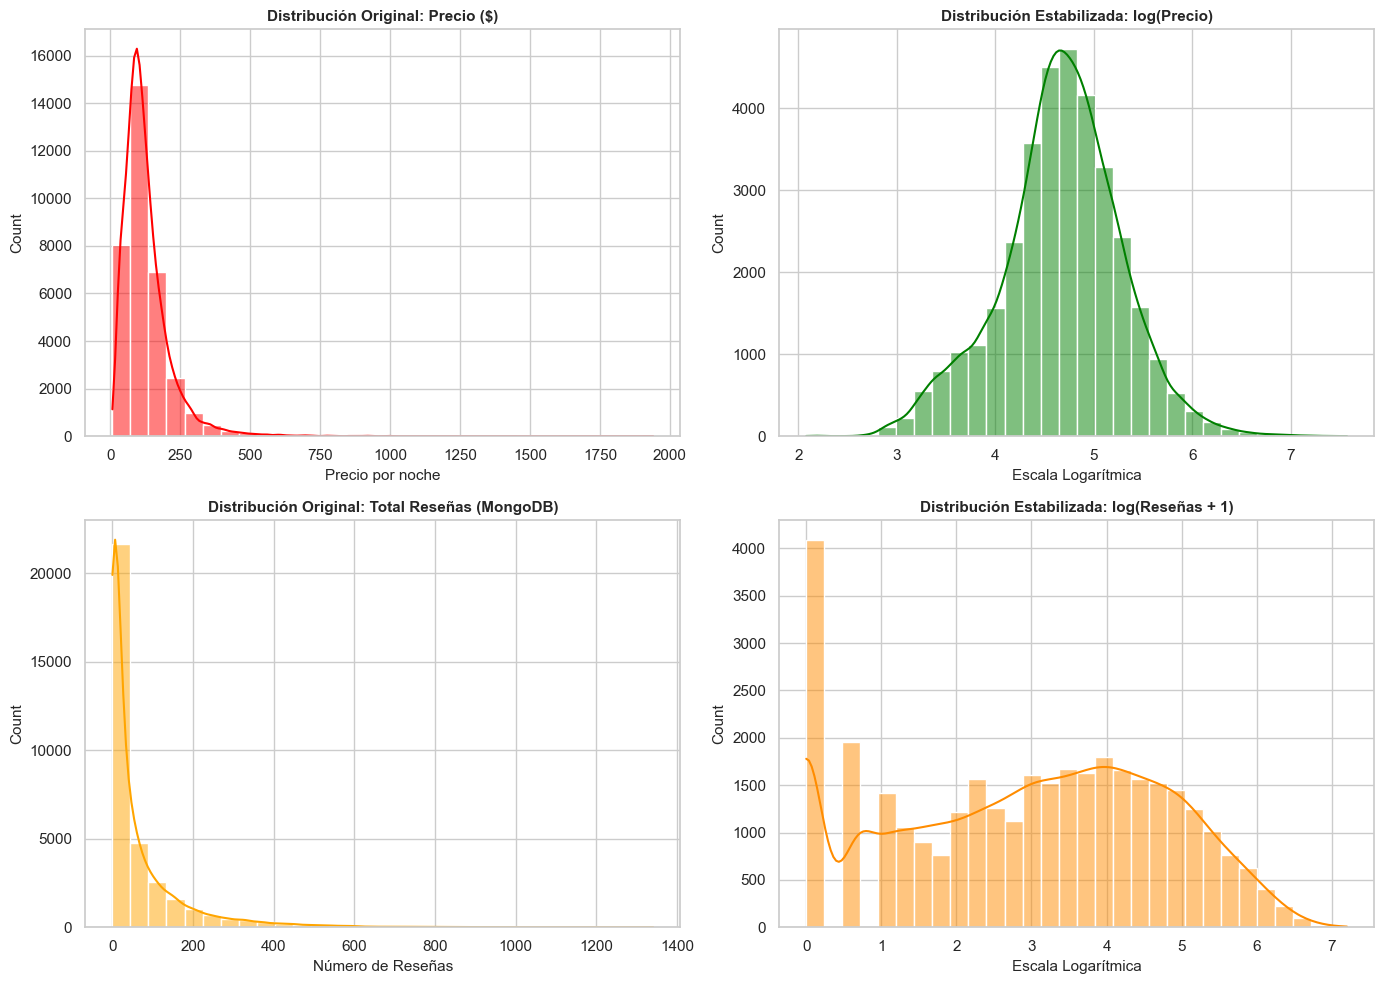


✅ TRANSFOMACIÓN POR SUSTITUCIÓN COMPLETADA:
   -> Variable 'price' ahora almacena su escala logarítmica. (Min: 2.079 | Max: 7.570)
   -> Variable 'total_reviews_historicas' ahora almacena su escala log1p. (Min: 0.000 | Max: 7.202)


In [69]:
print("⏳ Generando auditoría visual y aplicando transformaciones...")

# 1. NOTA DE INGENIERÍA: Mantenemos los clics en su formato original tras auditar su escala
print(f"   -> Máximo de clics detectado en Kafka: {df['total_clicks_acumulados'].max()}")
print("   -> Decisión: Se descarta el logaritmo en 'total_clicks_acumulados' por baja dispersión.")

# 2. Construcción del Lienzo de Auditoría Visual (Usa los datos originales antes de transformarlos)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- FILA 1: Variable Objetivo (Target - Precio) ---
sns.histplot(df['price'], kde=True, color='red', ax=axes[0, 0], bins=30)
axes[0, 0].set_title('Distribución Original: Precio ($)', fontsize=11, fontweight='bold')
axes[0, 0].set_xlabel('Precio por noche')

# Calculamos el logaritmo al vuelo solo para el gráfico de la derecha
sns.histplot(np.log(df['price']), kde=True, color='green', ax=axes[0, 1], bins=30)
axes[0, 1].set_title('Distribución Estabilizada: log(Precio)', fontsize=11, fontweight='bold')
axes[0, 1].set_xlabel('Escala Logarítmica')

# --- FILA 2: Reputación Histórica Consolidada (MongoDB Atlas) ---
sns.histplot(df['total_reviews_historicas'], kde=True, color='orange', ax=axes[1, 0], bins=30)
axes[1, 0].set_title('Distribución Original: Total Reseñas (MongoDB)', fontsize=11, fontweight='bold')
axes[1, 0].set_xlabel('Número de Reseñas')

# Calculamos el log1p al vuelo solo para el gráfico de la derecha
sns.histplot(np.log1p(df['total_reviews_historicas']), kde=True, color='darkorange', ax=axes[1, 1], bins=30)
axes[1, 1].set_title('Distribución Estabilizada: log(Reseñas + 1)', fontsize=11, fontweight='bold')
axes[1, 1].set_xlabel('Escala Logarítmica')

plt.tight_layout()
plt.show()

# =====================================================================
# 3. SUSTITUCIÓN REAL EN EL DATAFRAME (Sin crear columnas nuevas)
# =====================================================================
df['price'] = np.log(df['price'])
df['total_reviews_historicas'] = np.log1p(df['total_reviews_historicas'])

print("\n✅ TRANSFOMACIÓN POR SUSTITUCIÓN COMPLETADA:")
print(f"   -> Variable 'price' ahora almacena su escala logarítmica. (Min: {df['price'].min():.3f} | Max: {df['price'].max():.3f})")
print(f"   -> Variable 'total_reviews_historicas' ahora almacena su escala log1p. (Min: {df['total_reviews_historicas'].min():.3f} | Max: {df['total_reviews_historicas'].max():.3f})")

### 8.5. Purga del Identificador Operacional y Escalado Estructural de Predictores

#### 📝 Justificación Metodológica

Con la muestra verticalmente saneada y libre de valores atípicos, el *pipeline* ejecuta la última fase de adecuación matemática antes de la fase de codificación de categorías, dividida en dos acciones estratégicas:

1. **Remoción Definitiva del Identificador Operacional:** Habiendo cumplido su función de escudo de trazabilidad y unicidad en las fases de limpieza previas, se elimina del dataset la columna `listing_id`. Esto garantiza que los algoritmos de Machine Learning no procesen este índice administrativo secuencial como una característica cuantitativa, previniendo divisiones erróneas en las estructuras de los árboles.
2. **Escalado mediante Estandarización Estadística (`StandardScaler`):** Para homogeneizar las magnitudes de las variables cuantitativas nativas (evitando que atributos con rangos naturalmente más amplios como `maximum_nights` sesguen los vectores de peso del modelo sobre conteos discretos menores como `bedrooms`), se aplica una estandarización. El proceso transforma los vectores para fijar su media en $\mu = 0$ y su desviación estándar en $\sigma = 1$, manteniendo las proporciones óptimas para el aprendizaje del modelo.

In [70]:
print("⏳ Iniciando fase de remoción de ID y escalado estructural...")

# 1. Purga definitiva del identificador administrativo
if 'listing_id' in df.columns:
    df = df.drop(columns=['listing_id'])
    print("   -> 🗑️ Campo 'listing_id' eliminado con éxito.")

# 2. Definir estrictamente las columnas numéricas originales a escalar
columnas_a_escalar = [
    'accommodates', 'bedrooms', 'beds', 'bathrooms', 
    'minimum_nights', 'maximum_nights'
]

print("\n⚖️ Ejecutando estandarización estadística (StandardScaler)...")
scaler = StandardScaler()

# Clonamos el dataframe para trabajar con seguridad
df_escalado = df.copy()

# Aplicar el ajuste y transformación sobre las columnas seleccionadas
df_escalado[columnas_a_escalar] = scaler.fit_transform(df[columnas_a_escalar])

print("\n✅ PROCESO DE ESCALADO COMPLETADO:")
print(f"{'Variable / Atributo':<30} | {'Media (μ)':<12} | {'Desv. Estándar (σ)':<12} | {'Estado final'}")
print("-" * 75)
for col in df_escalado.columns:
    if col in columnas_a_escalar:
        media = df_escalado[col].mean()
        desviacion = df_escalado[col].std()
        print(f"{col:<30} | {media:<12.3f} | {desviacion:<12.3f} | ⚖️ Estandarizado")
    else:
        print(f"{col:<30} | {'-' :<12} | {'-' :<12} | 📦 Preservado original")

# Sincronizamos el dataset final de la sección
df = df_escalado.copy()
print(f"\n🔹 Estructura del dataset listo para el siguiente hito: {df.shape[0]:,} filas y {df.shape[1]} columnas.")

⏳ Iniciando fase de remoción de ID y escalado estructural...
   -> 🗑️ Campo 'listing_id' eliminado con éxito.

⚖️ Ejecutando estandarización estadística (StandardScaler)...

✅ PROCESO DE ESCALADO COMPLETADO:
Variable / Atributo            | Media (μ)    | Desv. Estándar (σ) | Estado final
---------------------------------------------------------------------------
neighbourhood_cleansed         | -            | -            | 📦 Preservado original
room_type                      | -            | -            | 📦 Preservado original
accommodates                   | -0.000       | 1.000        | ⚖️ Estandarizado
bedrooms                       | -0.000       | 1.000        | ⚖️ Estandarizado
beds                           | 0.000        | 1.000        | ⚖️ Estandarizado
bathrooms                      | -0.000       | 1.000        | ⚖️ Estandarizado
minimum_nights                 | 0.000        | 1.000        | ⚖️ Estandarizado
maximum_nights                 | 0.000        | 1.000        | ⚖

### 8.6. Adecuación y Tratamiento de Componentes Categóricos

#### 📝 Justificación Metodológica

Para dar por concluido el *pipeline* de preprocesamiento, se aborda la gestión de las variables cualitativas del vector de características. En lugar de aplicar una transformación numérica ciega y uniforme, se diseña una estrategia adaptada a la naturaleza y jerarquía de cada variable, priorizando la interpretabilidad y la eficiencia del espacio muestral:

1. **Codificación Ordinal Controlada (Label Encoding) para `room_type`:** Al presentar una baja cardinalidad (un espectro muy reducido de categorías independientes), la variable que define la tipología del alojamiento se transforma en una serie discreta de números enteros (`0`, `1`, `2`...). Este mapeo directo optimiza los recursos de computación y es asimilable de forma nativa por cualquier arquitectura de Machine Learning sin expandir las dimensiones de la matriz.
2. **Preservación de la Identidad Textual en `neighbourhood_cleansed`:** Tras analizar la estructura del atributo geográfico que recoge los barrios de Madrid, Málaga y Sevilla, se determina conservar los nombres originales de las ubicaciones en formato texto (estructurado internamente bajo el tipo `category` de Pandas). Se descarta explícitamente el uso de *One-Hot Encoding* para evitar la "maldición de la dimensionalidad" (la cual generaría cientos de columnas dispersas de ceros y unos que ralentizarían el entrenamiento de los árboles). Al mantener los nombres legibles, se garantiza la consistencia semántica del dataset, facilitando posteriores tareas de filtrado analítico, auditorías de negocio y la explotación del potencial nativo de algoritmos avanzados (como XGBoost o CatBoost) para gestionar variables categóricas de alta cardinalidad en su estado original.

In [71]:
print("⏳ Procesando variables categóricas preservando identidades...")

# ---------------------------------------------------------------------
# 1. CODIFICACIÓN ORDINAL CONTROLADA (room_type)
# ---------------------------------------------------------------------
# Convertimos el tipo de habitación a números discretos (0, 1, 2...)
if 'room_type' in df.columns:
    df['room_type'] = df['room_type'].astype('category')
    room_categories = df['room_type'].cat.categories
    room_mapping = {category: idx for idx, category in enumerate(room_categories)}
    df['room_type'] = df['room_type'].astype(str).map(room_mapping).astype(int)
    print("   -> ✅ 'room_type' codificado con éxito mediante mapeo ordinal.")

# ---------------------------------------------------------------------
# 2. SANEAMIENTO DE BARRIOS (PRESERVANDO TEXTO ORIGINAL)
# ---------------------------------------------------------------------
if 'neighbourhood_cleansed' in df.columns:
    # Homogeneizamos el texto: todo a minúsculas y quitamos espacios en los extremos
    df['neighbourhood_cleansed'] = df['neighbourhood_cleansed'].astype(str).str.lower().str.strip()
    
    # Lo convertimos a tipo 'category' de Pandas, que mantiene los nombres legibles
    # pero optimiza el rendimiento interno de la memoria RAM
    df['neighbourhood_cleansed'] = df['neighbourhood_cleansed'].astype('category')
    print("   -> ✅ 'neighbourhood_cleansed' preservado en formato texto (Categoría legible).")

# ---------------------------------------------------------------------
# 3. VERIFICACIÓN Y REPORTE FINAL DEL DATASET DE TRABAJO
# ---------------------------------------------------------------------
print("\n🚀 PIPELINE DE PREPROCESAMIENTO CONSOLIDADO:")
print("-" * 75)
print(f"   -> Dimensiones finales de la matriz analítica: {df.shape[0]:,} filas | {df.shape[1]} columnas.")
print("-" * 75)

print("\n👀 Inspección final de tipos de datos en el DataFrame:")
print(df.dtypes)

⏳ Procesando variables categóricas preservando identidades...
   -> ✅ 'room_type' codificado con éxito mediante mapeo ordinal.
   -> ✅ 'neighbourhood_cleansed' preservado en formato texto (Categoría legible).

🚀 PIPELINE DE PREPROCESAMIENTO CONSOLIDADO:
---------------------------------------------------------------------------
   -> Dimensiones finales de la matriz analítica: 34,186 filas | 11 columnas.
---------------------------------------------------------------------------

👀 Inspección final de tipos de datos en el DataFrame:
neighbourhood_cleansed      category
room_type                      int64
accommodates                 float64
bedrooms                     float64
beds                         float64
bathrooms                    float64
minimum_nights               float64
maximum_nights               float64
total_reviews_historicas     float64
total_clicks_acumulados        int64
price                        float64
dtype: object


## 9. División del Conjunto de Datos (Train/Test Split)

#### 📝 Justificación Metodológica

Para garantizar una evaluación objetiva de la capacidad de generalización de los modelos predictivos, se implementa una estrategia de partición estricta de la matriz analítica. Se descarta cualquier análisis predictivo sobre el total de la muestra, ya que esto induciría a un sesgo de optimismo y riesgo de sobreajuste (*overfitting*).

El dataset se fragmenta de forma aleatoria en dos subconjuntos independientes mediante una proporción clásica de **80% para entrenamiento** y **20% para test**:

1. **Conjunto de Entrenamiento (*Train Set*):** Destinado al ajuste de los hiperparámetros y funciones de coste de los algoritmos de Machine Learning.
2. **Conjunto de Validación/Test (*Test Set*):** Actúa como una auditoría ciega externa. Al quedar completamente aislado del proceso de aprendizaje, permite medir de forma transparente métricas reales de error (como el MAE o el RMSE) ante propiedades nuevas en el mercado PropTech.

Para asegurar la reproducibilidad exacta del experimento en futuras ejecuciones o auditorías del tribunal, el proceso se blinda fijando una semilla de aleatoriedad pseudoaleatoria constante (`random_state=42`).

In [72]:
print("⏳ Iniciando la partición del dataset en conjuntos de entrenamiento y test...")

# 1. Aislar la variable objetivo (Y) y los predictores/características (X)
# Recuerda que 'price' ya almacena el valor transformado en escala logarítmica
y = df['price']
X = df.drop(columns=['price'])

# 2. Ejecutar la división estricta 80% / 20%
# Usamos random_state=42 para garantizar que la división siempre sea idéntica
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    random_state=42
)

# 3. Reporte estructural de control de dimensiones
print("\n✅ PARTICIÓN COMPLETADA CON ÉXITO:")
print("-" * 65)
print(f"   -> Matriz Original Total:       {df.shape[0]:,} registros | {df.shape[1]} columnas.")
print("-" * 65)
print(f"   -> 🏋️ Set de ENTRENAMIENTO (80%): {X_train.shape[0]:,} filas")
print(f"   -> 🎓 Set de TEST          (20%): {X_test.shape[0]:,} filas")
print("-" * 65)
print(f"   -> Número de Predictores (X):   {X_train.shape[1]} variables analíticas.")
print(f"   -> Vector Objetivo (y):         1 variable ('price' en escala log).")
print("-" * 65)

# Verificación rápida de que no hay fugas de información o nulos extraños
print(f"\n🔹 Control de integridad en Entrenamiento: {X_train.isnull().sum().sum()} valores nulos.")
print(f"🔹 Control de integridad en Test:          {X_test.isnull().sum().sum()} valores nulos.")

⏳ Iniciando la partición del dataset en conjuntos de entrenamiento y test...

✅ PARTICIÓN COMPLETADA CON ÉXITO:
-----------------------------------------------------------------
   -> Matriz Original Total:       34,186 registros | 11 columnas.
-----------------------------------------------------------------
   -> 🏋️ Set de ENTRENAMIENTO (80%): 27,348 filas
   -> 🎓 Set de TEST          (20%): 6,838 filas
-----------------------------------------------------------------
   -> Número de Predictores (X):   10 variables analíticas.
   -> Vector Objetivo (y):         1 variable ('price' en escala log).
-----------------------------------------------------------------

🔹 Control de integridad en Entrenamiento: 0 valores nulos.
🔹 Control de integridad en Test:          0 valores nulos.
